# Yu-Gi-Oh! Dataset Exploratory Data Analysis

This notebook will be used to get some insights from scrapped Yu-Gi-Oh! Card data. 

Data Mining Week 1 - Scrapping & EDA Technique

> Source: https://ygoprodeck.com

# Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import json

from pathlib import Path
from dataclasses import dataclass

In [2]:
@dataclass
class Config:
    ROOT_DIR: Path = Path(os.getcwd())
    DATA_DIR: Path = ROOT_DIR / "data"
    OUTPUT_DIR: Path = ROOT_DIR / "output"
    SEED: int = 42


cfg = Config()
cfg.OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Root directory: {cfg.ROOT_DIR}")
print(f"Data directory: {cfg.DATA_DIR}")
print(f"Output directory: {cfg.OUTPUT_DIR}")

Root directory: /home/ryz/data/collage/sem 3/datmin/Repo/Week 2/tugas-scrapping-eda
Data directory: /home/ryz/data/collage/sem 3/datmin/Repo/Week 2/tugas-scrapping-eda/data
Output directory: /home/ryz/data/collage/sem 3/datmin/Repo/Week 2/tugas-scrapping-eda/output


# Get Dataset

In [3]:
df = pd.read_csv(cfg.DATA_DIR / "yugioh_cards.csv")
df.index = df["id"]
df.drop(columns=["id"], inplace=True)
df.head(5)

,name,type,frame_type,description,race,attribute,archetype,level,rank,link_value,...,image_url_small,tcgplayer_price,cardmarket_price,ebay_price,amazon_price,ban_tcg,ban_ocg,ban_goat,set_count,sets
id,,,,,,,,,,,,,,,,,,,,,
80181649,"""A Case for K9""",Spell Card,spell,"When this card is activated: You can add 1 ""K9...",Continuous,NaN,K9,NaN,NaN,NaN,...,https://images.ygoprodeck.com/images/cards_sma...,0.17,0.23,0.00,0.00,Limited,NaN,NaN,4,"[{'set_name': 'Justice Hunters', 'set_code': '..."
34541863,"""A"" Cell Breeding Device",Spell Card,spell,"During each of your Standby Phases, put 1 A-Co...",Continuous,NaN,Alien,NaN,NaN,NaN,...,https://images.ygoprodeck.com/images/cards_sma...,0.22,0.10,0.99,24.45,NaN,NaN,NaN,1,"[{'set_name': 'Force of the Breaker', 'set_cod..."
64163367,"""A"" Cell Incubator",Spell Card,spell,Each time an A-Counter(s) is removed from play...,Continuous,NaN,Alien,NaN,NaN,NaN,...,https://images.ygoprodeck.com/images/cards_sma...,0.22,0.12,1.25,0.50,NaN,NaN,NaN,1,"[{'set_name': ""Gladiator's Assault"", 'set_code..."
91231901,"""A"" Cell Recombination Device",Spell Card,spell,Target 1 face-up monster on the field; send 1 ...,Quick-Play,NaN,Alien,NaN,NaN,NaN,...,https://images.ygoprodeck.com/images/cards_sma...,0.13,0.06,0.99,0.50,NaN,NaN,NaN,1,"[{'set_name': 'Invasion: Vengeance', 'set_code..."
73262676,"""A"" Cell Scatter Burst",Spell Card,spell,"Select 1 face-up ""Alien"" monster you control. ...",Quick-Play,NaN,Alien,NaN,NaN,NaN,...,https://images.ygoprodeck.com/images/cards_sma...,0.16,0.14,2.00,9.76,NaN,NaN,NaN,1,"[{'set_name': 'Strike of Neos', 'set_code': 'S..."


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 14533 entries, 80181649 to 76080032
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   name              14533 non-null  object 
 1   type              14533 non-null  object 
 2   frame_type        14533 non-null  object 
 3   description       14533 non-null  object 
 4   race              14530 non-null  object 
 5   attribute         9343 non-null   object 
 6   archetype         8786 non-null   object 
 7   level             8978 non-null   float64
 8   rank              0 non-null      float64
 9   link_value        473 non-null    float64
 10  atk               9343 non-null   float64
 11  def               8870 non-null   float64
 12  image_url         14533 non-null  object 
 13  image_url_small   14533 non-null  object 
 14  tcgplayer_price   14533 non-null  float64
 15  cardmarket_price  14533 non-null  float64
 16  ebay_price        14533 non-null  f

From that information, we know that rank doesn't have any information contains. Even though, in Yu-Gi-Oh! itself there's a rank on XYZ Monster

I also won't use any image on this analytics

In [5]:
df.drop(columns=["image_url", "image_url_small", "rank"], inplace=True)
print(f"Dataframe shape after dropping columns: {df.shape}")
print(f"Columns after dropping: {df.columns.tolist()}")
print(f"Number of unique card names: {df['name'].nunique()}")

Dataframe shape after dropping columns: (14533, 20)
Columns after dropping: ['name', 'type', 'frame_type', 'description', 'race', 'attribute', 'archetype', 'level', 'link_value', 'atk', 'def', 'tcgplayer_price', 'cardmarket_price', 'ebay_price', 'amazon_price', 'ban_tcg', 'ban_ocg', 'ban_goat', 'set_count', 'sets']
Number of unique card names: 14533


# Exploratory Data Analysis

## Check Missing Values

/home/ryz/miniforge3/envs/dsml/lib/python3.10/site-packages/missingno/missingno.py:61: UserWarning: Plotting a sparkline on an existing axis is not currently supported. To remove this warning, set sparkline=False.
  warnings.warn(


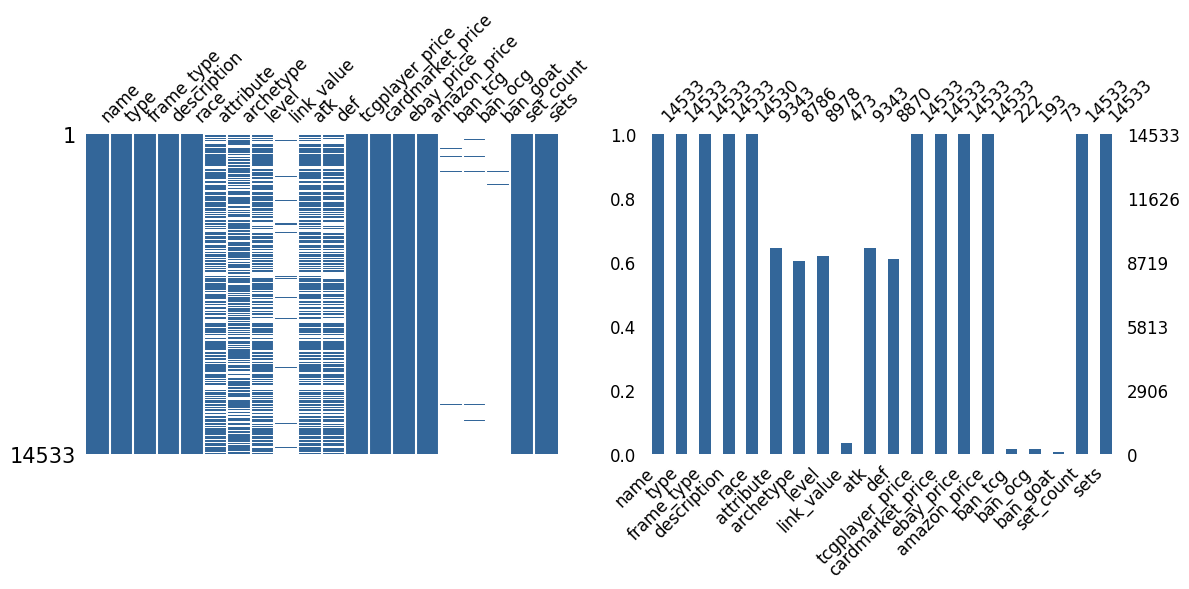

In [6]:
import missingno as msno

fig,ax = plt.subplots(1,2,figsize=(12,6))
ax = ax.flatten()

msno.matrix(df, ax=ax[0], fontsize=12, color=(0.2, 0.4, 0.6))
msno.bar(df, ax=ax[1], fontsize=12, color=(0.2, 0.4, 0.6))
plt.tight_layout()

From this we can see that, the image there's a lot missing here may be occur because some `card type` may don't have some other feature. Like `spell card` doesn't have attack and defence

<Axes: >

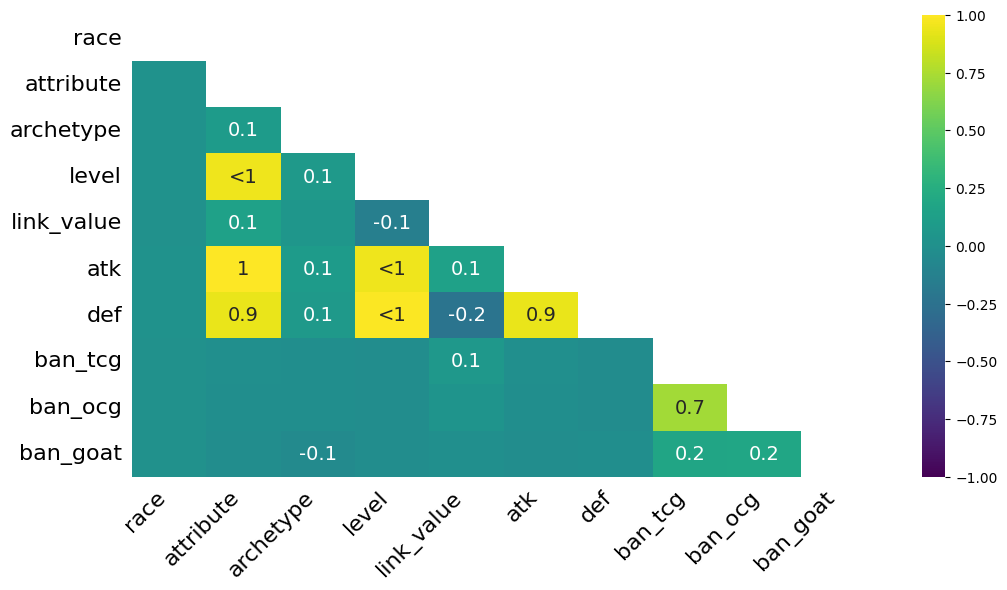

In [7]:
msno.heatmap(df, figsize=(12,6), cmap="viridis")

Yeah, as you can see some of the missing are highly correlated one to another for missing. One of ther high correlated feature is level againts atk and def, logically it happen because the spell and trap card don't have it

/tmp/ipykernel_168157/4190082471.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.isna().mean() * 100)


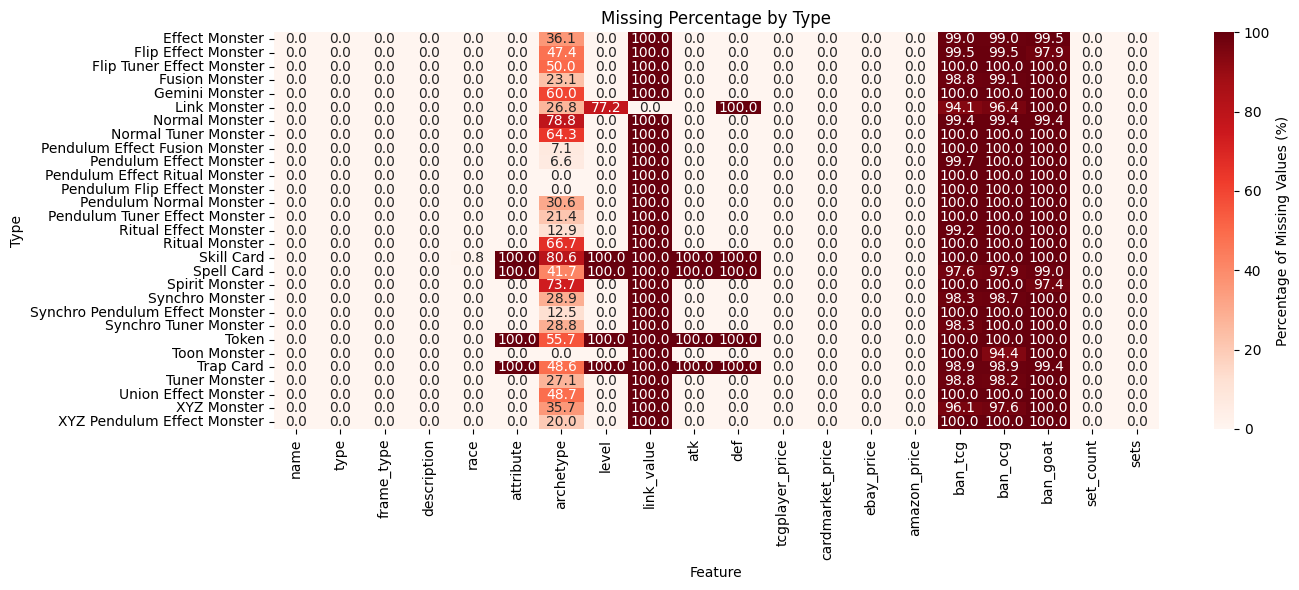

In [8]:
missing_by_type = (
    df.groupby("type")
      .apply(lambda g: g.isna().mean() * 100)
)

plt.figure(figsize=(14, 6))
sns.heatmap(
    missing_by_type,
    annot=True,
    fmt=".1f",
    cmap="Reds",
    cbar_kws={"label": "Percentage of Missing Values (%)"}
)

plt.title("Missing Percentage by Type")
plt.ylabel("Type")
plt.xlabel("Feature")
plt.tight_layout()
plt.show()

As you can see the missingness highly depends on the card type. For the banlist will highly because banned cards are very rare.

In [9]:
num_cols = df.select_dtypes(include=[int,float]).columns.tolist()
cat_cols = df.select_dtypes(include=[object]).columns.tolist()

print(f"Numerical columns: {num_cols}")
print(f"Categorical columns: {cat_cols}")

Numerical columns: ['level', 'link_value', 'atk', 'def', 'tcgplayer_price', 'cardmarket_price', 'ebay_price', 'amazon_price', 'set_count']
Categorical columns: ['name', 'type', 'frame_type', 'description', 'race', 'attribute', 'archetype', 'ban_tcg', 'ban_ocg', 'ban_goat', 'sets']


## Numeric Analysis

### Distributions (Histogram + KDE )

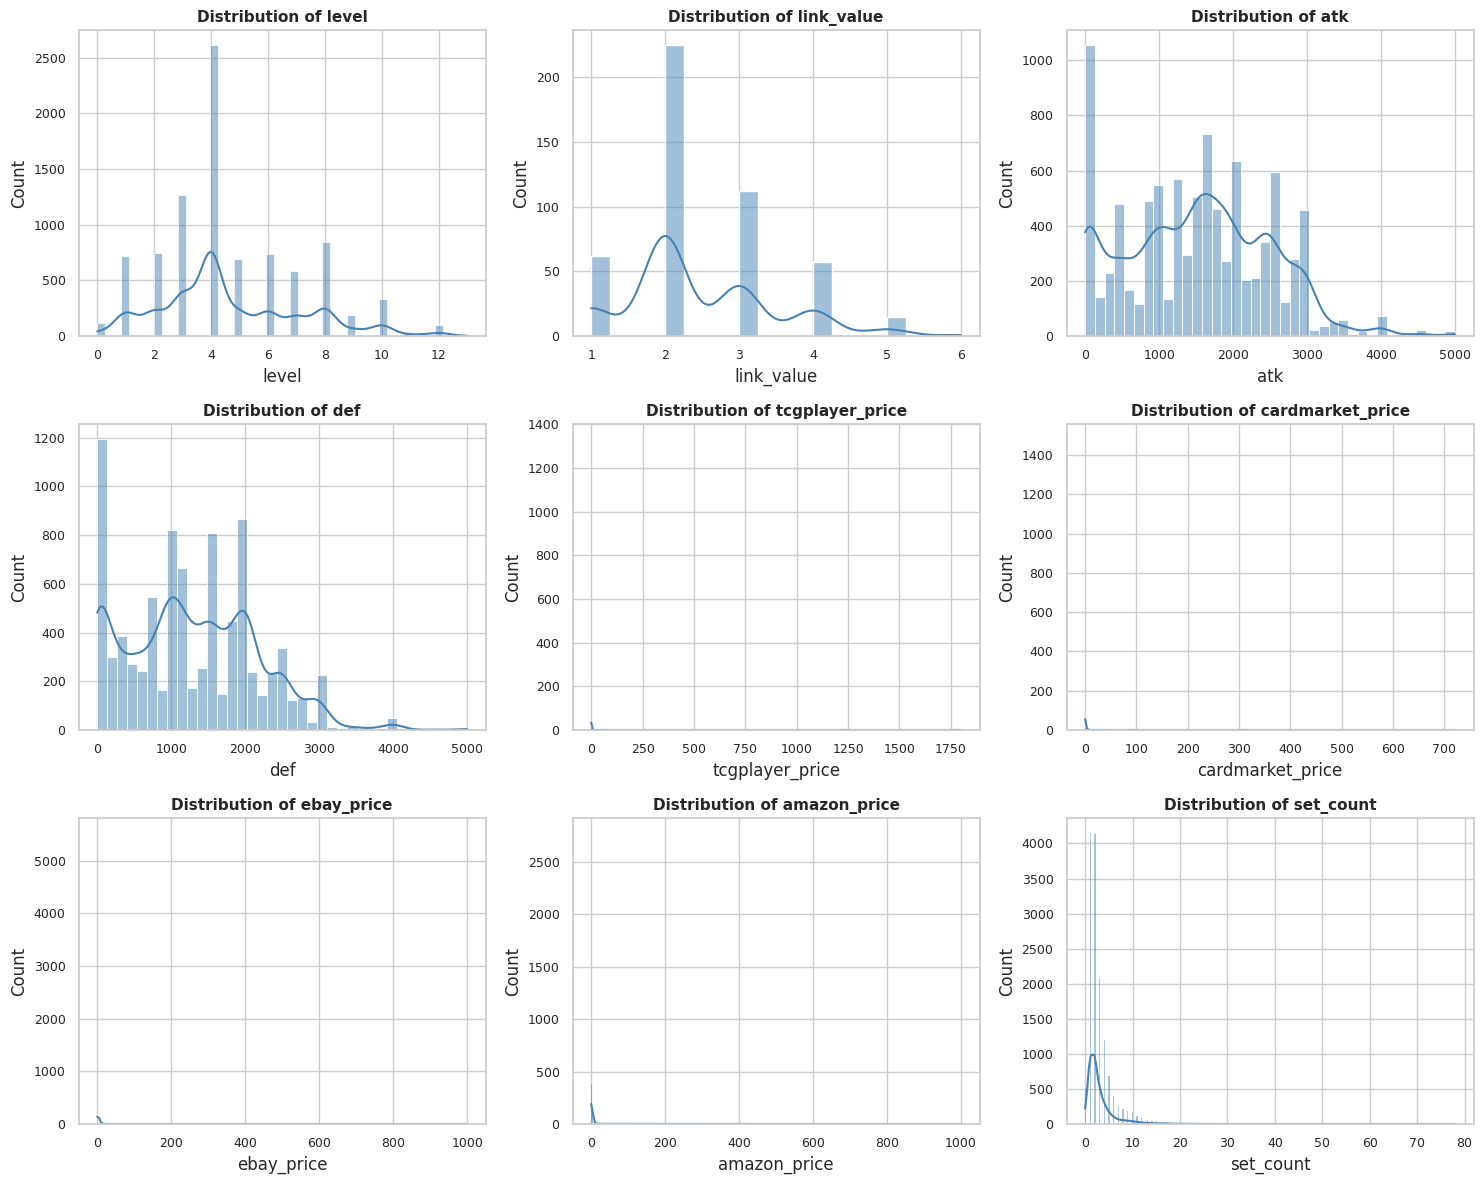

,count,mean,std,min,25%,50%,75%,max
level,8978.0,4.66,2.50,0.0,3.00,4.00,6.00,13.00
link_value,473.0,2.46,1.00,1.0,2.00,2.00,3.00,6.00
atk,9343.0,1519.82,963.11,-1.0,800.00,1500.00,2200.00,5000.00
def,8870.0,1287.50,883.09,-1.0,600.00,1200.00,2000.00,5000.00
tcgplayer_price,14533.0,1.16,18.82,0.0,0.12,0.19,0.33,1800.00
cardmarket_price,14533.0,0.85,10.36,0.0,0.06,0.12,0.25,720.91
ebay_price,14533.0,3.84,29.45,0.0,0.99,0.99,2.49,999.99
amazon_price,14533.0,3.52,20.65,0.0,0.25,0.66,1.73,999.99
set_count,14533.0,3.06,3.49,0.0,1.00,2.00,4.00,78.00


Skewness (>>1 = heavy right tail):


tcgplayer_price     68.77
cardmarket_price    44.97
ebay_price          27.26
amazon_price        26.29
set_count            5.54
link_value           0.74
level                0.63
def                  0.39
atk                  0.21
dtype: float64

In [10]:
import math

sns.set_theme(style="whitegrid")
n_cols_grid = 3
n_rows_grid = math.ceil(len(num_cols) / n_cols_grid)

fig, axes = plt.subplots(n_rows_grid, n_cols_grid, figsize=(15, 12))
axes = axes.flatten()

for ax, col in zip(axes, num_cols):
    sns.histplot(df[col].dropna(), kde=True, ax=ax, color="steelblue", edgecolor="white")
    ax.set_title(f"Distribution of {col}", fontsize=11, fontweight="bold")
    ax.set_xlabel(col)
    ax.tick_params(labelsize=9)

for ax in axes[len(num_cols):]:
    ax.set_visible(False)

plt.tight_layout()
plt.savefig(cfg.OUTPUT_DIR / "numeric_hist_kde.png", dpi=150, bbox_inches="tight")
plt.show()

# Tabular backbone for everything that follows
display(df[num_cols].describe().T.round(2))
print("Skewness (>>1 = heavy right tail):")
display(df[num_cols].skew(numeric_only=True).sort_values(ascending=False).round(2))


From the analysis above there a still question need to be answered,

1. prices are **extremely right-skewed** (skew 26–69, max \$1,800 vs median \$0.19),
2. combat stats are roughly bell-shaped. So we re-plot the same 9 columns four ways:

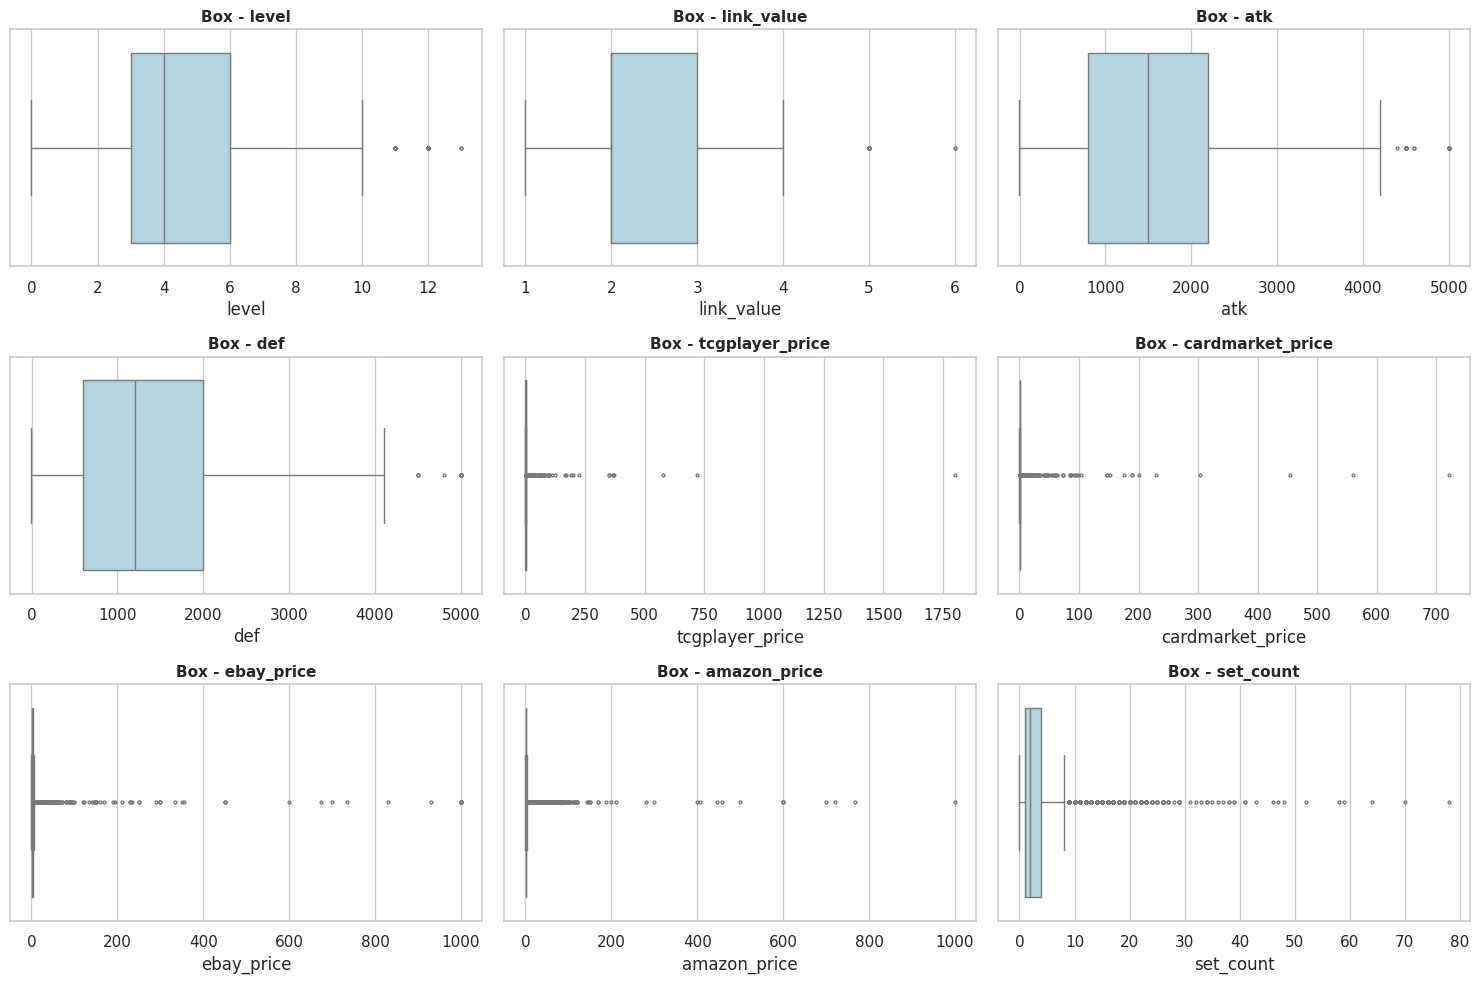

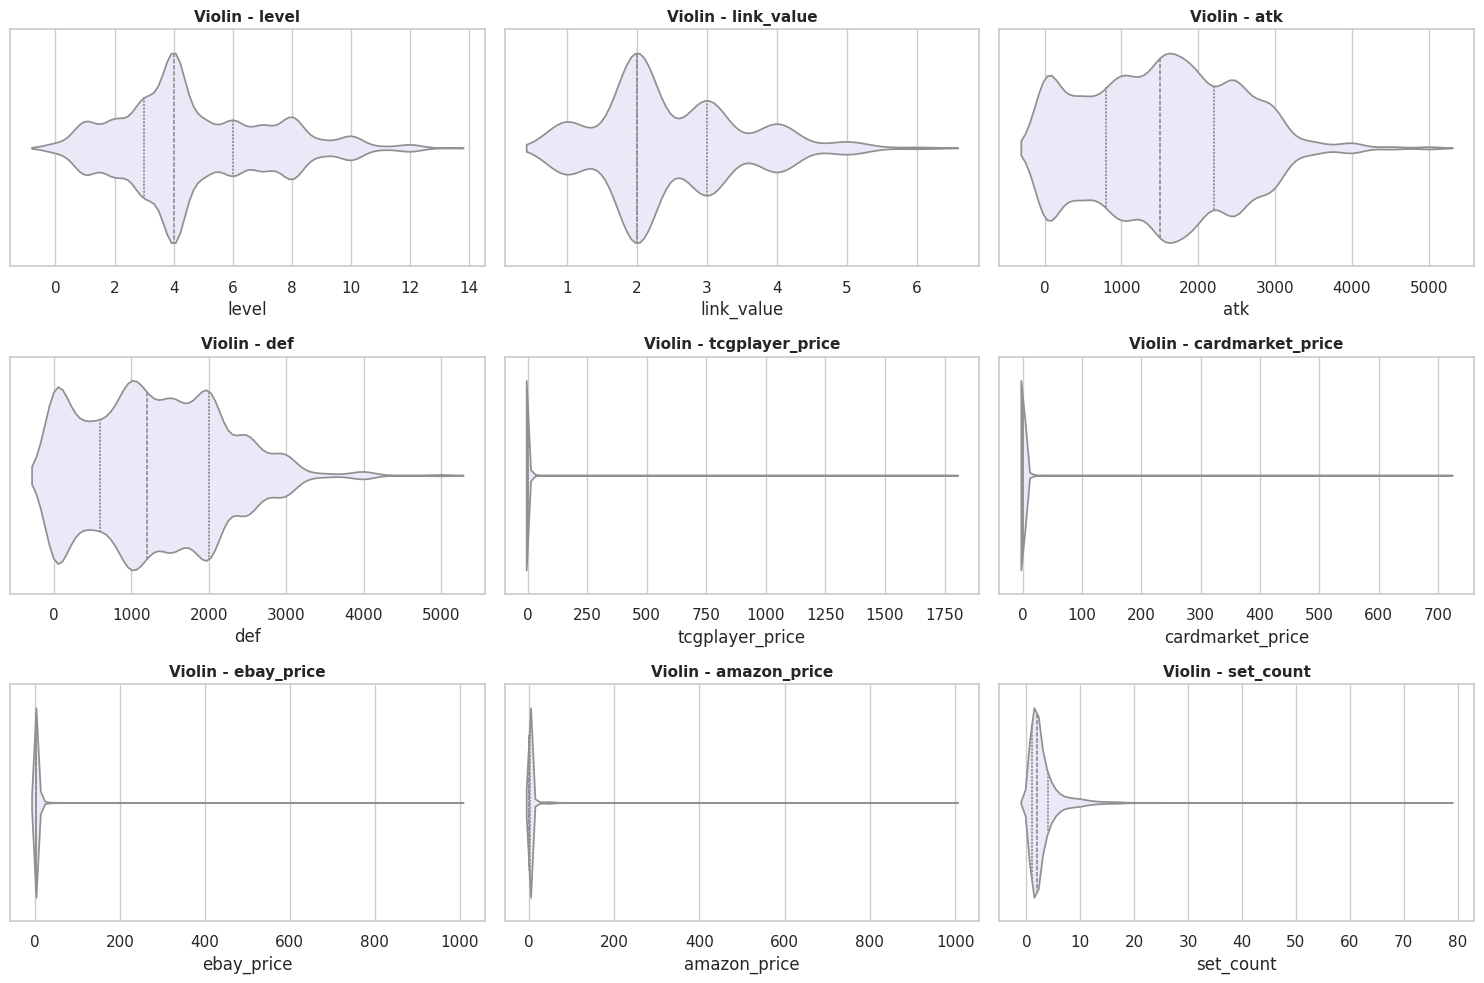

In [11]:
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()
for ax, col in zip(axes, num_cols):
    sns.boxplot(x=df[col].dropna(), ax=ax, color="lightblue", fliersize=2)
    ax.set_title(f"Box - {col}", fontsize=11, fontweight="bold")
plt.tight_layout()
plt.savefig(cfg.OUTPUT_DIR / "numeric_box.png", dpi=150, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()
for ax, col in zip(axes, num_cols):
    sns.violinplot(x=df[col].dropna(), ax=ax, color="lavender", inner="quartile")
    ax.set_title(f"Violin - {col}", fontsize=11, fontweight="bold")
plt.tight_layout()
plt.savefig(cfg.OUTPUT_DIR / "numeric_violin.png", dpi=150, bbox_inches="tight")
plt.show()


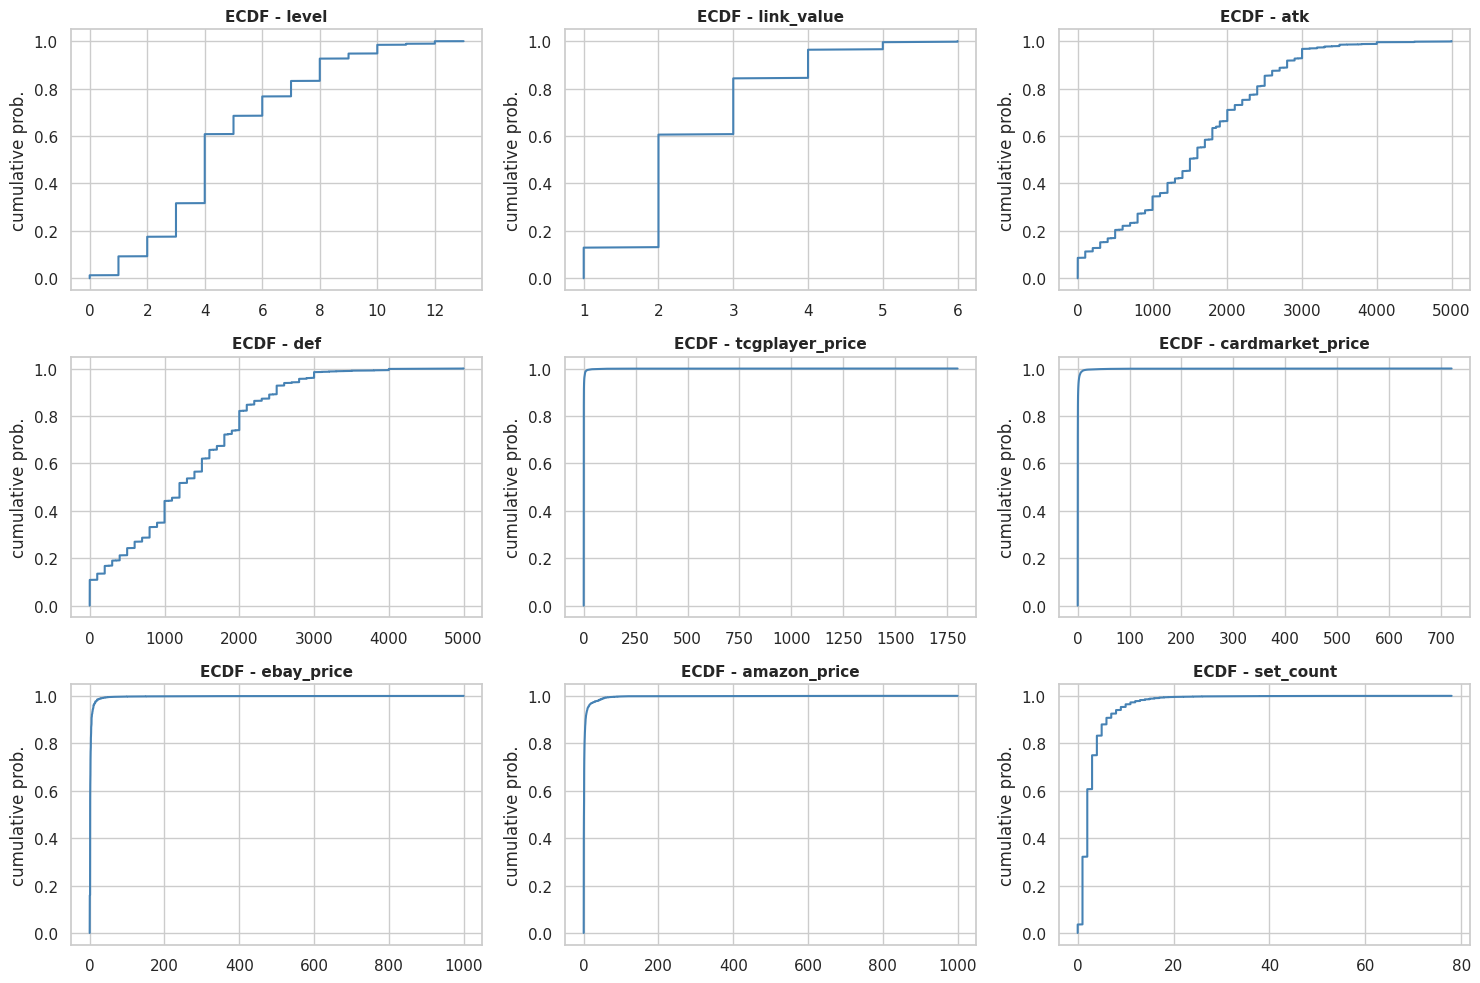

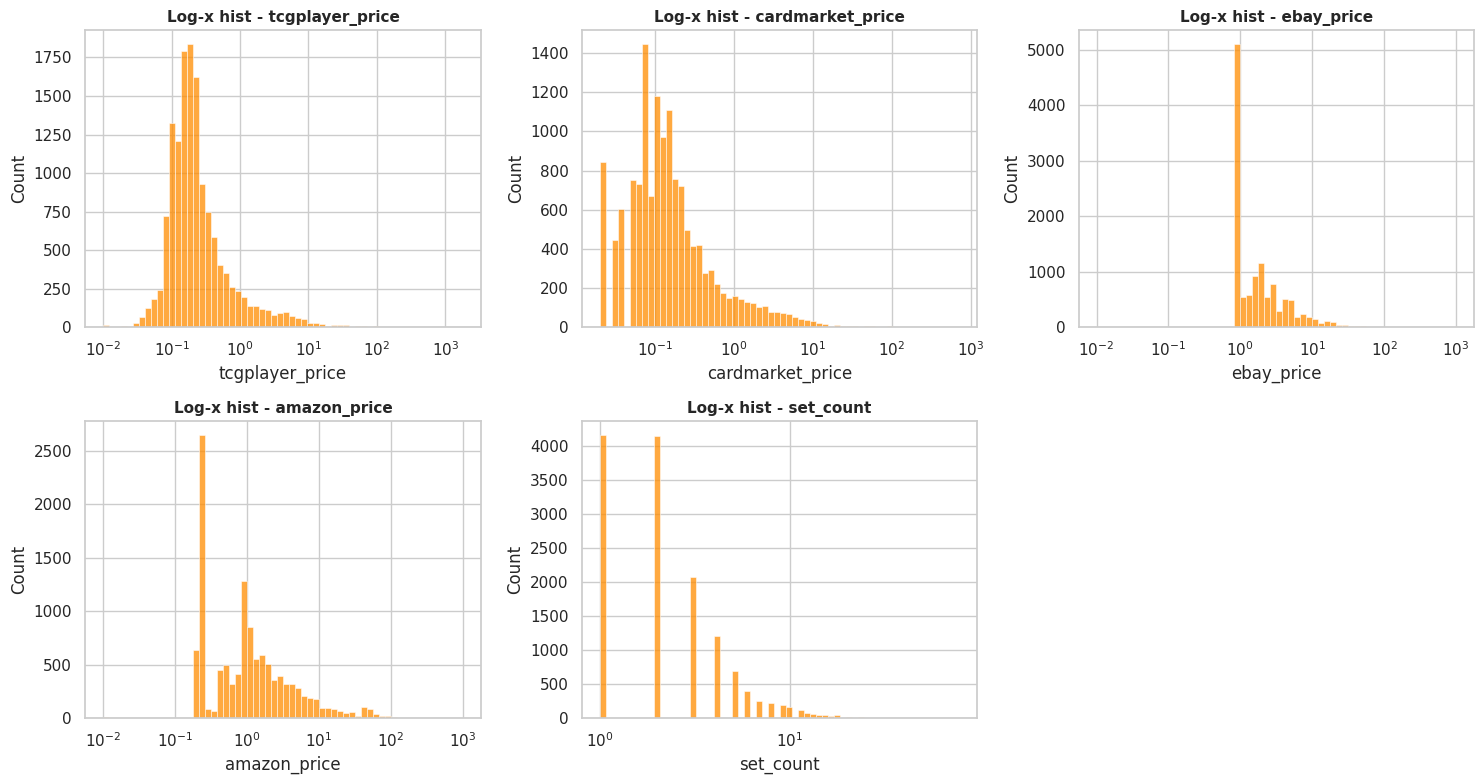

In [12]:
# ECDF + log-scale histograms
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()
for ax, col in zip(axes, num_cols):
    s = df[col].dropna().sort_values()
    ax.plot(s.values, np.linspace(0, 1, len(s)), color="steelblue", lw=1.5)
    ax.set_title(f"ECDF - {col}", fontsize=11, fontweight="bold")
    ax.set_ylabel("cumulative prob.")
plt.tight_layout()
plt.savefig(cfg.OUTPUT_DIR / "numeric_ecdf.png", dpi=150, bbox_inches="tight")
plt.show()

# Log-scale histograms 
skewed = ["tcgplayer_price", "cardmarket_price", "ebay_price", "amazon_price", "set_count"]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for ax, col in zip(axes, skewed):
    s = df[col].dropna()
    sns.histplot(s[s > 0], bins=60, log_scale=True, ax=ax, color="darkorange", edgecolor="white")
    ax.set_title(f"Log-x hist - {col}", fontsize=11, fontweight="bold")
axes[-1].set_visible(False)
plt.tight_layout()
plt.savefig(cfg.OUTPUT_DIR / "numeric_loghist.png", dpi=150, bbox_inches="tight")
plt.show()


`atk` (median 1,500) and `def` (median 1,200) are mound-shaped around playable stat lines; `level` piles on 3–4–7–8 (median 4, mean 4.66); `link_value` is discrete 1–6 (median 2). All four **price** columns collapse near zero (medians \$0.12–\$0.99) with a long collectible tail - that is why every price plot needs log/ECDF treatment, and why mean ≫ median.

### Correlation plot (Pearson vs Spearman)

Pearson = linear agreement (sensitive to whale prices); Spearman = rank agreement (robust). `level/link_value` are mutually exclusive mechanics (Link monsters have no level), so their pairwise correlation is NaN by construction - that blank cell is expected, not a bug.

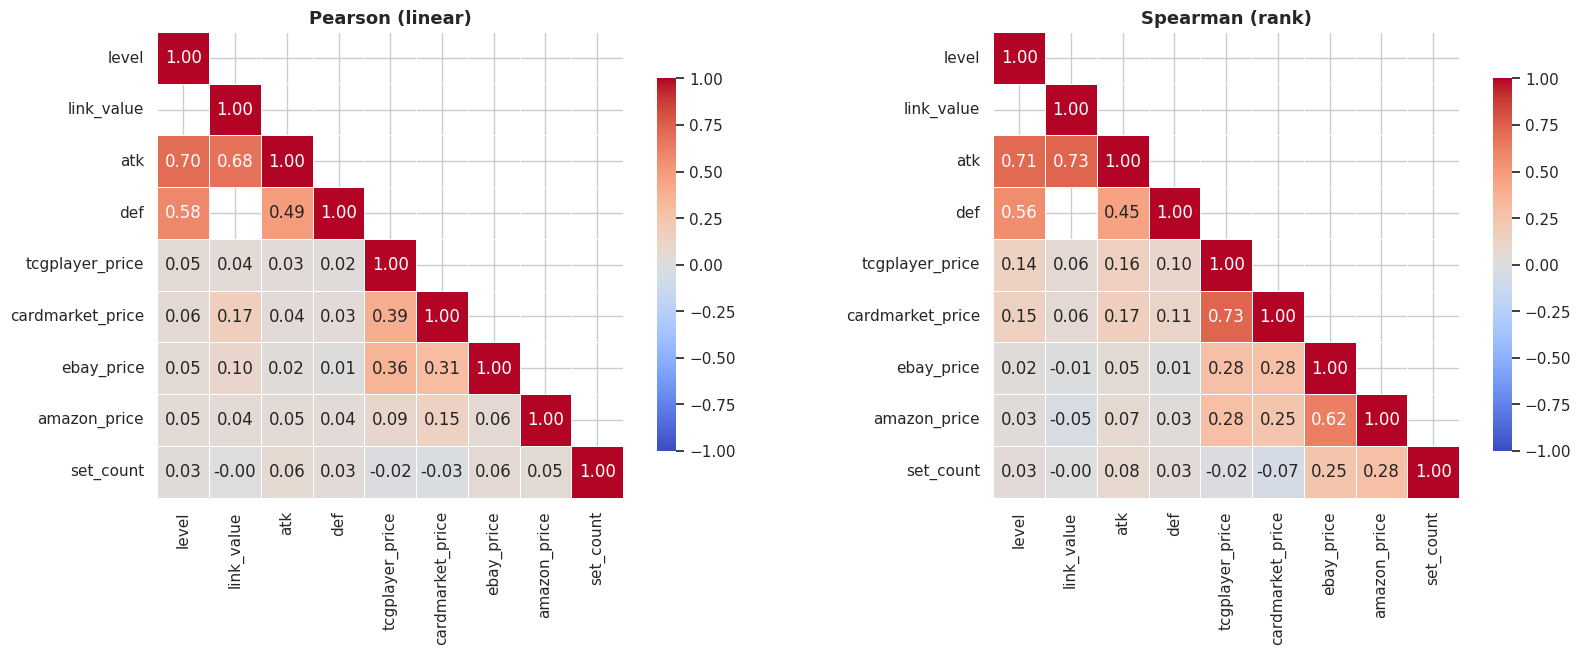

Top-10 absolute Pearson pairs (off-diagonal):
atk               level               0.698
                  link_value          0.676
def               level               0.579
                  atk                 0.491
cardmarket_price  tcgplayer_price     0.395
ebay_price        tcgplayer_price     0.356
                  cardmarket_price    0.306
cardmarket_price  link_value          0.165
amazon_price      cardmarket_price    0.148
ebay_price        link_value          0.098

Top-10 absolute Spearman pairs (off-diagonal):
atk               link_value          0.734
cardmarket_price  tcgplayer_price     0.728
atk               level               0.713
amazon_price      ebay_price          0.619
def               level               0.556
                  atk                 0.455
ebay_price        cardmarket_price    0.284
amazon_price      tcgplayer_price     0.282
set_count         amazon_price        0.282
ebay_price        tcgplayer_price     0.275


In [13]:
corr_pearson = df[num_cols].corr(method="pearson")
corr_spearman = df[num_cols].corr(method="spearman")

fig, axes = plt.subplots(1, 2, figsize=(17, 6.5))
mask = np.triu(np.ones_like(corr_pearson, dtype=bool), k=1)  # show lower triangle + diag
for ax, corr, title in zip(axes, [corr_pearson, corr_spearman], ["Pearson (linear)", "Spearman (rank)"]):
    sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1,
                square=True, linewidths=.5, cbar_kws={"shrink": .8}, ax=ax)
    ax.set_title(title, fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(cfg.OUTPUT_DIR / "numeric_corr.png", dpi=150, bbox_inches="tight")
plt.show()

print("Top-10 absolute Pearson pairs (off-diagonal):")
tmp = corr_pearson.where(np.tril(np.ones_like(corr_pearson, dtype=bool), k=-1)).stack()
print((tmp.reindex(tmp.abs().sort_values(ascending=False).index).head(10)).round(3).to_string())
print("\nTop-10 absolute Spearman pairs (off-diagonal):")
tmp_s = corr_spearman.where(np.tril(np.ones_like(corr_spearman, dtype=bool), k=-1)).stack()
print((tmp_s.reindex(tmp_s.abs().sort_values(ascending=False).index).head(10)).round(3).to_string())


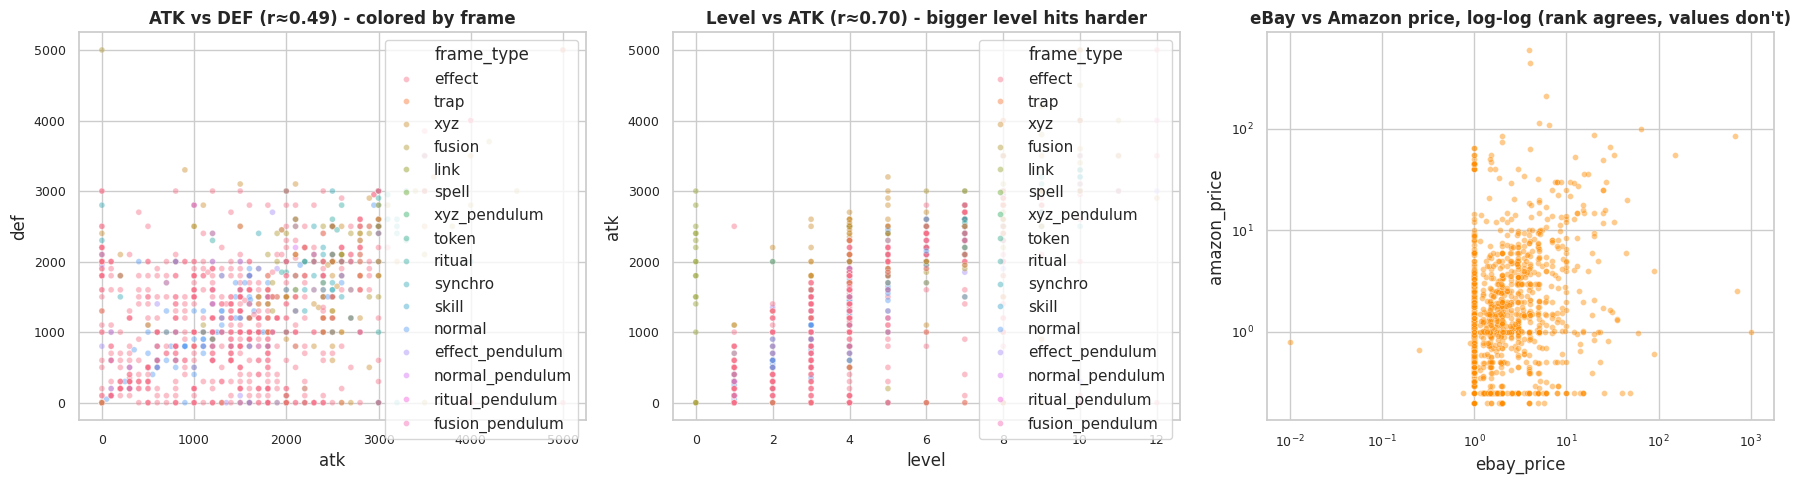

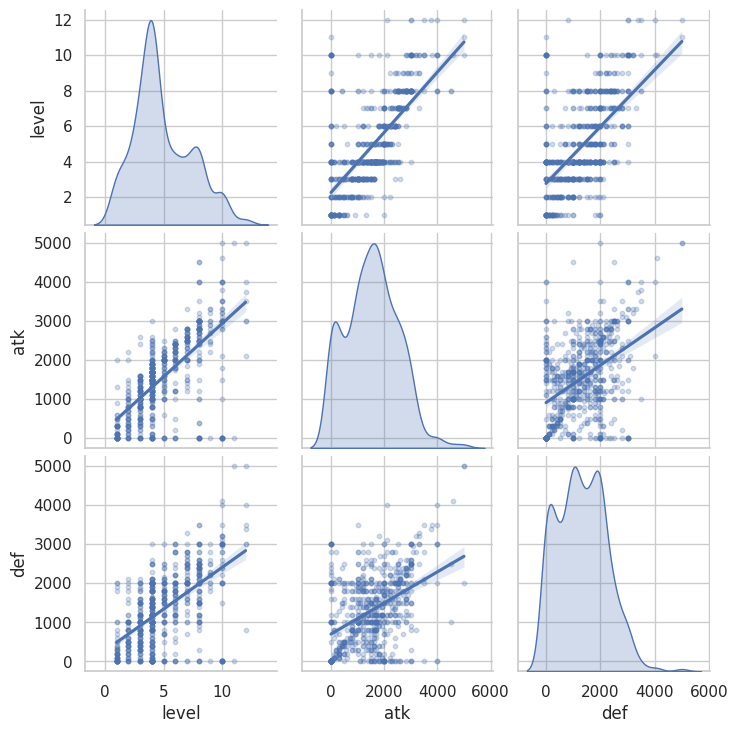

In [14]:
# Scatter-truth layer
sample = df.sample(min(2000, len(df)), random_state=cfg.SEED)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.scatterplot(data=sample, x="atk", y="def", hue="frame_type", alpha=0.45, s=18, ax=axes[0])
axes[0].set_title("ATK vs DEF (r≈0.49) - colored by frame", fontweight="bold")
sns.scatterplot(data=sample, x="level", y="atk", hue="frame_type", alpha=0.45, s=18, ax=axes[1])
axes[1].set_title("Level vs ATK (r≈0.70) - bigger level hits harder", fontweight="bold")
sns.scatterplot(data=sample, x="ebay_price", y="amazon_price", alpha=0.45, s=18, color="darkorange", ax=axes[2])
axes[2].set_xscale("log"); axes[2].set_yscale("log")
axes[2].set_title("eBay vs Amazon price, log-log (rank agrees, values don't)", fontweight="bold")
for ax in axes: ax.tick_params(labelsize=9)
plt.tight_layout()
plt.savefig(cfg.OUTPUT_DIR / "numeric_scatters.png", dpi=150, bbox_inches="tight")
plt.show()

# Combat-only pairplot 
mon = df[df["atk"].notna() & df["def"].notna() & df["level"].notna()]
sns.pairplot(mon.sample(min(800, len(mon)), random_state=cfg.SEED)[["level", "atk", "def"]],
             kind="reg", diag_kind="kde", plot_kws={"scatter_kws": {"alpha": .25, "s": 10}})
plt.savefig(cfg.OUTPUT_DIR / "numeric_pairplot.png", dpi=150, bbox_inches="tight")
plt.show()


A tight **combat block** (`level–atk` ≈ 0.70, `atk–def` ≈ 0.49, `link–atk` ≈ 0.68) - stronger monsters sit at higher levels. A separate weak **price block** (`ebay–amazon` Spearman 0.62 but Pearson only 0.06: the rank order agrees, the dollar values don't, because a few whale listings blow up linearity). `set_count` (reprints) is ~orthogonal to everything (|r| < 0.1): being reprinted often neither implies strength nor value. Cross-block (stats vs price) correlations are ≈ 0 - **flavor/rarity, not stats, drives price**.

### Outlier detection (IQR rule + boxen + price zoom)

We use Tukey IQR fences (`[Q1 − 1.5·IQR, Q3 + 1.5·IQR]`) per column

Because prices are non-Gaussian. For collectibles, "outliers" = the chase cards, so we count them rather than delete them.

In [15]:
def iqr_report(s: pd.Series):
    s = s.dropna()
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    out = ((s < lo) | (s > hi))
    return pd.Series({"n": len(s), "Q1": q1, "Q3": q3, "IQR": iqr,
                      "lo": lo, "hi": hi, "n_out": int(out.sum()),
                      "pct_out": round(100 * out.mean(), 2),
                      "max": s.max(), "min": s.min()})

out_tbl = pd.DataFrame({c: iqr_report(df[c]) for c in num_cols}).T
display(out_tbl.round(2).sort_values("pct_out", ascending=False))
out_tbl.to_csv(cfg.OUTPUT_DIR / "numeric_iqr_outliers.csv")

# Who are the extreme points? name the top-5 priciest + strongest
print("Top-5 by tcgplayer_price:"); display(df.nlargest(5, "tcgplayer_price")[["name", "type", "tcgplayer_price", "set_count"]])
print("Top-5 by ATK:"); display(df.nlargest(5, "atk")[["name", "type", "atk", "def", "level"]])


,n,Q1,Q3,IQR,lo,hi,n_out,pct_out,max,min
cardmarket_price,14533.0,0.06,0.25,0.19,-0.23,0.54,1959.0,13.48,720.91,0.0
amazon_price,14533.0,0.25,1.73,1.48,-1.97,3.95,1925.0,13.25,999.99,0.0
tcgplayer_price,14533.0,0.12,0.33,0.21,-0.20,0.64,1922.0,13.23,1800.00,0.0
ebay_price,14533.0,0.99,2.49,1.50,-1.26,4.74,1757.0,12.09,999.99,0.0
set_count,14533.0,1.00,4.00,3.00,-3.50,8.50,872.0,6.00,78.00,0.0
link_value,473.0,2.00,3.00,1.00,0.50,4.50,17.0,3.59,6.00,1.0
level,8978.0,3.00,6.00,3.00,-1.50,10.50,138.0,1.54,13.00,0.0
atk,9343.0,800.00,2200.00,1400.00,-1300.00,4300.00,39.0,0.42,5000.00,-1.0
def,8870.0,600.00,2000.00,1400.00,-1500.00,4100.00,13.0,0.15,5000.00,-1.0


Top-5 by tcgplayer_price:


,name,type,tcgplayer_price,set_count
id,,,,
30757396,Blood Mefist,Synchro Monster,1800.00,2
10000,Ten Thousand Dragon,Effect Monster,718.19,1
501000006,"Chimaera, the Master of Beasts",Effect Monster,575.00,1
63028558,Anotherverse Solaria,Normal Monster,370.02,0
90844184,Garma Sword,Ritual Monster,367.00,1


Top-5 by ATK:


,name,type,atk,def,level
id,,,,,
37542782,Cyberdark End Dragon,Fusion Monster,5000.0,3800.0,12.0
62873545,Dragon Master Knight,Fusion Monster,5000.0,5000.0,12.0
58931850,Dragon Master Lords,XYZ Monster,5000.0,5000.0,12.0
12381100,Dragon Master Magia,Fusion Monster,5000.0,4000.0,12.0
56863746,Drytron Meteonis DA Draconids,Ritual Effect Monster,5000.0,5000.0,12.0


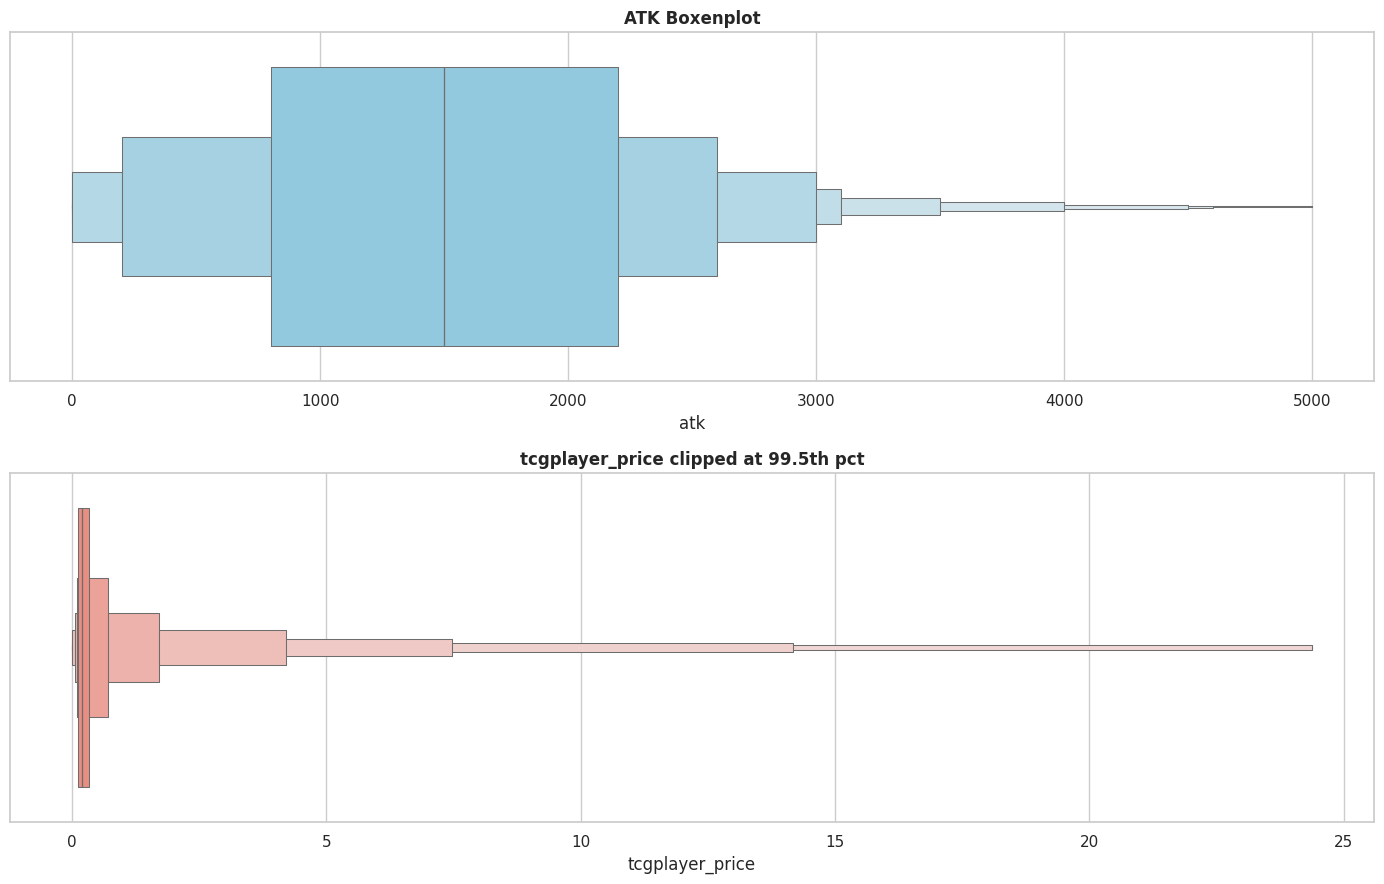

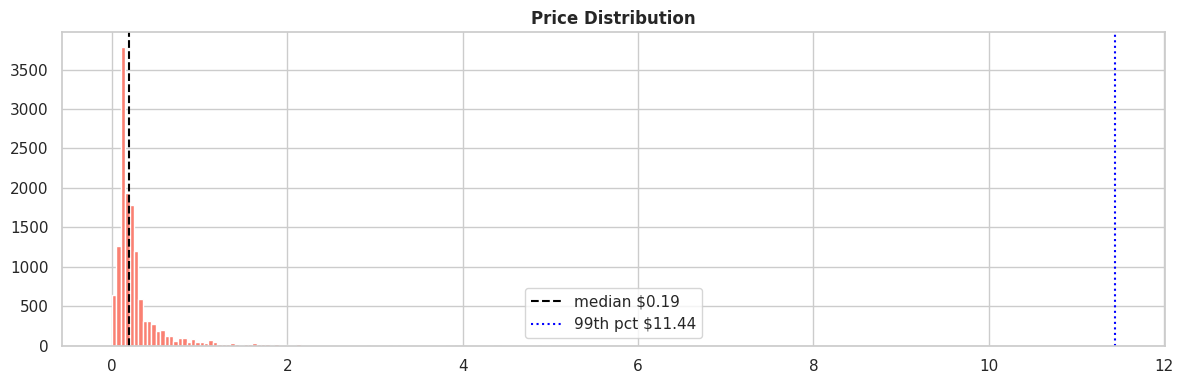

In [16]:
# Boxenplot (letter-value plot: better than box for 14k rows) + price strip zoom
fig, axes = plt.subplots(2, 1, figsize=(14, 9))
sns.boxenplot(x=df["atk"].dropna(), color="skyblue", ax=axes[0])
axes[0].set_title("ATK Boxenplot", fontweight="bold")
sns.boxenplot(x=df["tcgplayer_price"].clip(upper=df["tcgplayer_price"].quantile(0.995)).dropna(),
              color="salmon", ax=axes[1])
axes[1].set_title("tcgplayer_price clipped at 99.5th pct",
                  fontweight="bold")
plt.tight_layout()
plt.savefig(cfg.OUTPUT_DIR / "numeric_outlier_boxen.png", dpi=150, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(12, 4))
s = df["tcgplayer_price"]
ax.hist(s[s <= 5], bins=100, color="salmon", edgecolor="white")
ax.axvline(s.median(), color="black", ls="--", label=f"median ${s.median():.2f}")
ax.axvline(s.quantile(0.99), color="blue", ls=":", label=f"99th pct ${s.quantile(0.99):.2f}")
ax.set_title("Price Distribution",
             fontweight="bold")
ax.legend(); plt.tight_layout()
plt.savefig(cfg.OUTPUT_DIR / "numeric_price_zoom.png", dpi=150, bbox_inches="tight")
plt.show()


Prices flag 12–13% IQR-outliers - expected, not dirty data (a \$0.19-median market with \$100+ chase cards). Combat outliers are rare and real: 39 cards above ATK 4,300 (boss monsters at 4,500–5,000), 138 cards above level 10.5 (Level 11–13 gods). 

## Categorical Analysis

Object columns: 
- `type` (29), 
- `frame_type` (17), 
- `race` (86), 
- `attribute` (7 + NaN), 
- `archetype` (659), 
- `ban_tcg/ocg/goat` (3 each, ultra-sparse), 
- and free text `name`/`description`/`sets`. 


,n_unique (incl. NaN),n_unique (excl. NaN),missing %,top value,top share %
archetype,660,659,39.54,NaN,39.5
race,87,86,0.02,Normal,16.6
type,29,29,0.00,Effect Monster,35.3
frame_type,17,17,0.00,effect,41.0
attribute,8,7,35.71,NaN,35.7
ban_tcg,4,3,98.47,NaN,98.5
ban_ocg,4,3,98.67,NaN,98.7
ban_goat,4,3,99.50,NaN,99.5


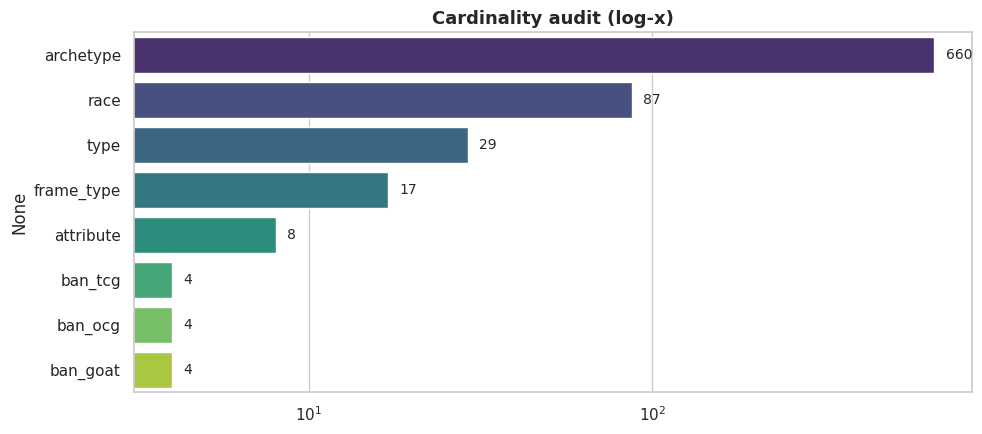

In [17]:
focus_cats = ["type", "frame_type", "race", "attribute", "archetype", "ban_tcg", "ban_ocg", "ban_goat"]
card = pd.DataFrame({
    "n_unique (incl. NaN)": [df[c].nunique(dropna=False) for c in focus_cats],
    "n_unique (excl. NaN)": [df[c].nunique(dropna=True) for c in focus_cats],
    "missing %": (df[focus_cats].isna().mean() * 100).round(2),
    "top value": [df[c].value_counts(dropna=False).index[0] for c in focus_cats],
    "top share %": [(df[c].value_counts(dropna=False, normalize=True).iloc[0] * 100).round(1) for c in focus_cats],
}).sort_values("n_unique (incl. NaN)", ascending=False)
display(card)
card.to_csv(cfg.OUTPUT_DIR / "categorical_cardinality.csv")

fig, ax = plt.subplots(figsize=(10, 4.5))
sns.barplot(x=card["n_unique (incl. NaN)"].values, y=card.index, hue=card.index,
            palette="viridis", legend=False, ax=ax)
ax.set_xscale("log")
for i, v in enumerate(card["n_unique (incl. NaN)"].values):
    ax.text(v * 1.08, i, str(v), va="center", fontsize=10)
ax.set_title("Cardinality audit (log-x)", fontweight="bold", fontsize=13)
plt.tight_layout(); plt.savefig(cfg.OUTPUT_DIR / "categorical_cardinality.png", dpi=150, bbox_inches="tight")
plt.show()


/tmp/ipykernel_168157/1513221080.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df["type"], order=df["type"].value_counts().index, palette="tab20", ax=axes[0])
/tmp/ipykernel_168157/1513221080.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df["frame_type"], order=df["frame_type"].value_counts().index, palette="Set2", ax=axes[1])
/tmp/ipykernel_168157/1513221080.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df["attribute"].fillna("None (Spell/Trap)"),


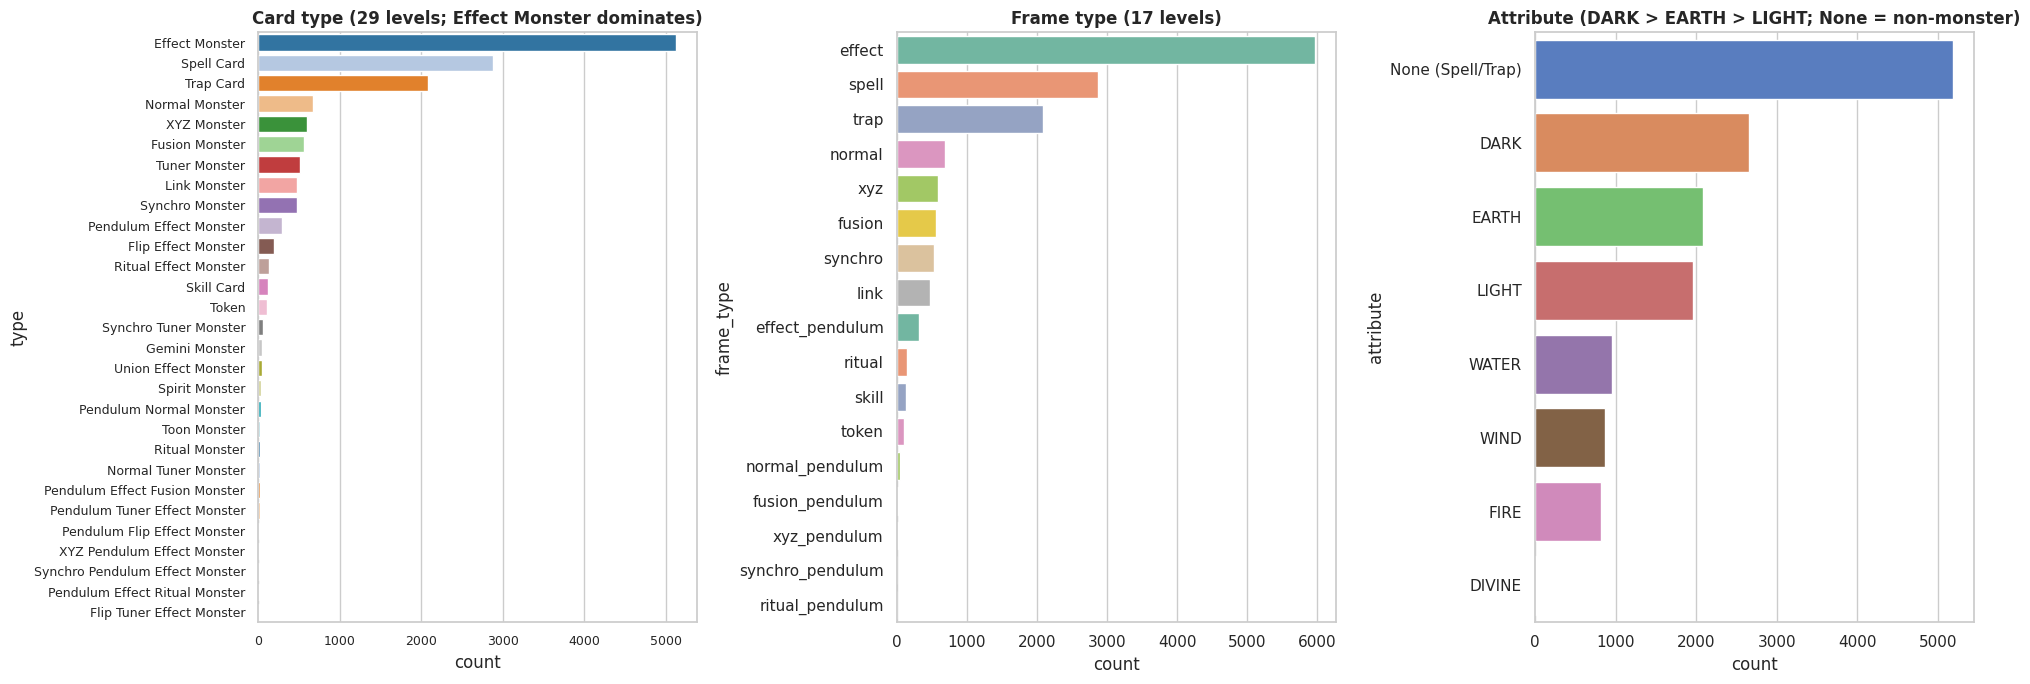

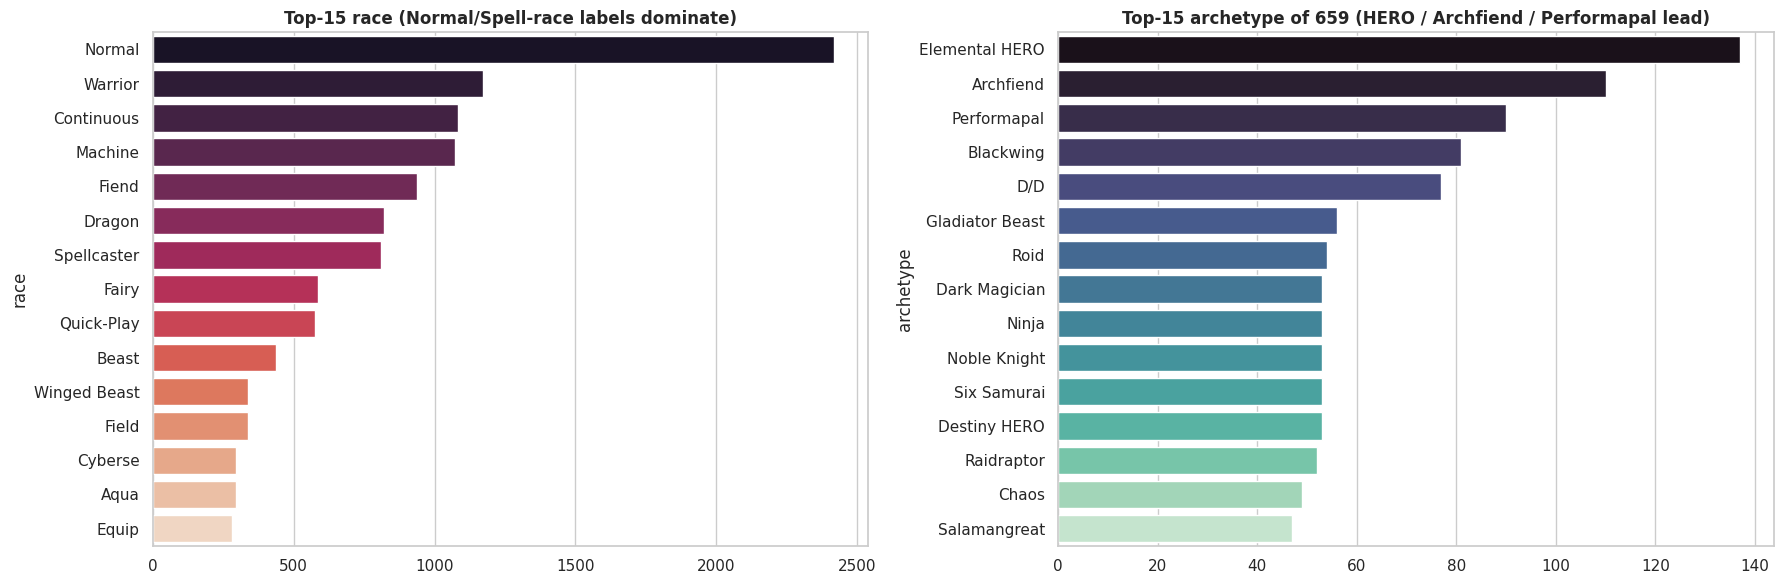

Archetype coverage: top-15 = 1018 cards (7.0%), NaN (no archetype) = 5747 (39.5%)


In [18]:
# Core game taxonomy
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
sns.countplot(y=df["type"], order=df["type"].value_counts().index, palette="tab20", ax=axes[0])
axes[0].set_title("Card type (29 levels; Effect Monster dominates)", fontweight="bold")
axes[0].tick_params(labelsize=9)
sns.countplot(y=df["frame_type"], order=df["frame_type"].value_counts().index, palette="Set2", ax=axes[1])
axes[1].set_title("Frame type (17 levels)", fontweight="bold")
sns.countplot(y=df["attribute"].fillna("None (Spell/Trap)"),
              order=df["attribute"].fillna("None (Spell/Trap)").value_counts().index,
              palette="muted", ax=axes[2])
axes[2].set_title("Attribute (DARK > EARTH > LIGHT; None = non-monster)", fontweight="bold")
plt.tight_layout(); plt.savefig(cfg.OUTPUT_DIR / "categorical_core.png", dpi=150, bbox_inches="tight")
plt.show()

# Race (86 levels!) and archetype (659!) -> Top-15 only, rest grouped as "Other"
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
top_race = df["race"].value_counts().head(15)
sns.barplot(x=top_race.values, y=top_race.index, hue=top_race.index, palette="rocket", legend=False, ax=axes[0])
axes[0].set_title("Top-15 race (Normal/Spell-race labels dominate)", fontweight="bold")
top_arch = df["archetype"].value_counts().head(15)
sns.barplot(x=top_arch.values, y=top_arch.index, hue=top_arch.index, palette="mako", legend=False, ax=axes[1])
axes[1].set_title("Top-15 archetype of 659 (HERO / Archfiend / Performapal lead)", fontweight="bold")
plt.tight_layout(); plt.savefig(cfg.OUTPUT_DIR / "categorical_race_archetype.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Archetype coverage: top-15 = {top_arch.sum()} cards ({top_arch.sum()/len(df)*100:.1f}%), "
      f"NaN (no archetype) = {df['archetype'].isna().sum()} ({df['archetype'].isna().mean()*100:.1f}%)")


Main hero archetype mostly dominate by `main character decks`. Elemental HERO and Perfomapal are the deck that used by MC on Yu-Gi-Oh GX and Zexal

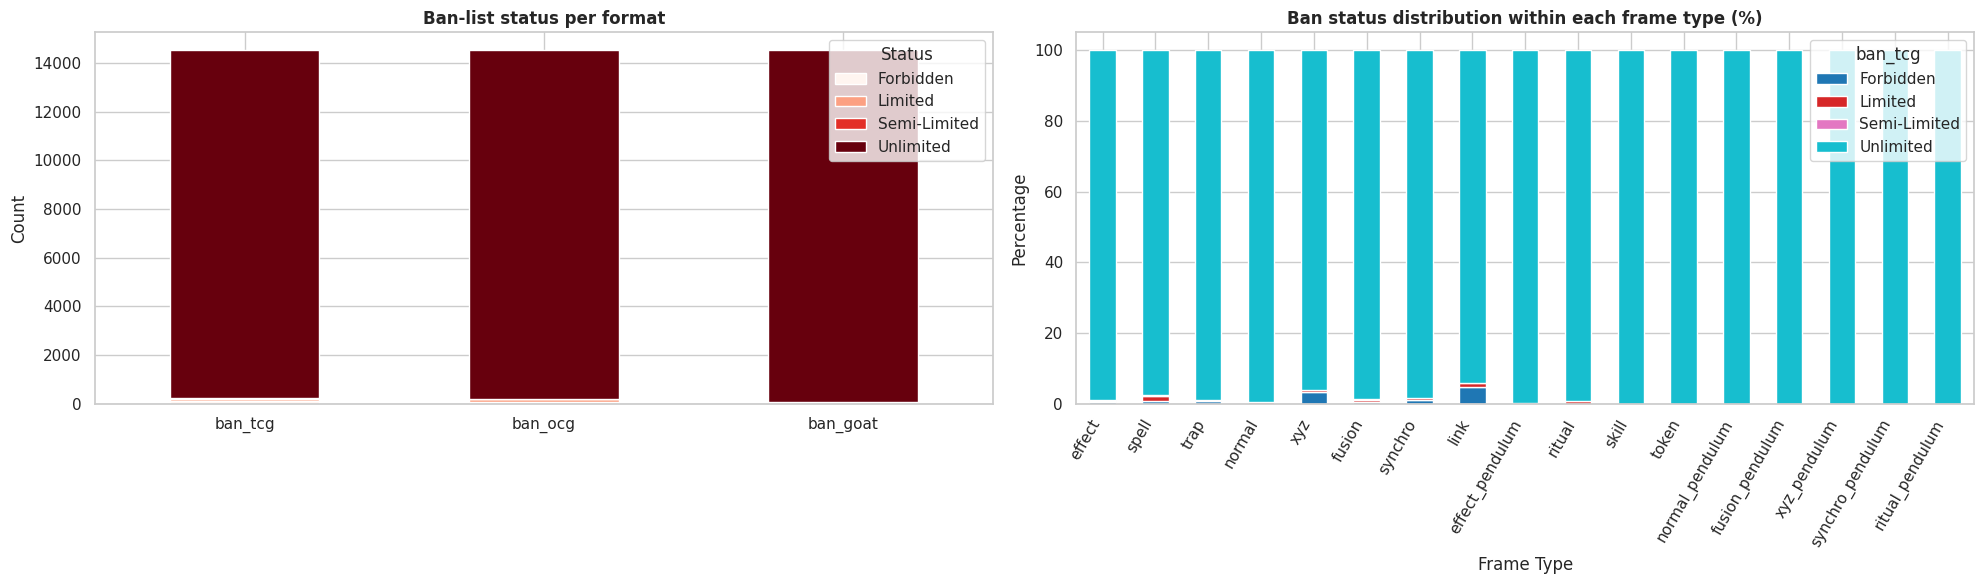

ban_tcg,Forbidden,Limited,Semi-Limited,Unlimited
frame_type,,,,
effect,32,21,5,5907
spell,20,44,4,2810
trap,15,8,0,2058
normal,0,4,0,681
xyz,19,4,0,568
fusion,3,3,1,557
synchro,6,3,0,520
link,22,6,0,445
effect_pendulum,0,1,0,313


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(20, 6))

ban_cols = ["ban_tcg", "ban_ocg", "ban_goat"]

ban = (
    pd.DataFrame({
        c: df[c].fillna("Unlimited").value_counts()
        for c in ban_cols
    }).fillna(0)
)

ban = ban.reindex(["Forbidden", "Limited", "Semi-Limited", "Unlimited"], fill_value=0)

ban.T.plot(kind="bar",stacked=True,ax=axes[0],colormap="Reds",edgecolor="white",)

axes[0].set_title("Ban-list status per format",fontweight="bold")
axes[0].set_xlabel("")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=0)
axes[0].legend(title="Status")


ct = pd.crosstab(df["frame_type"].fillna("Unknown"),df["ban_tcg"].fillna("Unlimited"),normalize="index") * 100
ct = ct.reindex(columns=["Forbidden", "Limited", "Semi-Limited", "Unlimited"],fill_value=0)

# sort by frequency for readability
frame_order = (df["frame_type"].fillna("Unknown").value_counts().index)
ct = ct.loc[frame_order]


ct.plot(kind="bar",stacked=True,ax=axes[1],colormap="tab10",edgecolor="white")

axes[1].set_title("Ban status distribution within each frame type (%)",fontweight="bold")
axes[1].set_xlabel("Frame Type")
axes[1].set_ylabel("Percentage")
plt.setp(axes[1].get_xticklabels(),rotation=60,ha="right")
axes[1].legend(title="ban_tcg")

plt.tight_layout()
plt.savefig(cfg.OUTPUT_DIR / "categorical_bans.png",dpi=150,bbox_inches="tight")
plt.show()

display(
    pd.crosstab(
        df["frame_type"].fillna("Unknown"),
        df["ban_tcg"].fillna("Unlimited")
    )
    .sort_values("Unlimited", ascending=False)
)

low-cardinality game axes (`type`/`frame`/`attribute`) are plottable in full; `race` (86) and especially `archetype` (659, 40% NaN) need Top-N treatment and - for modelling - target/frequency encoding or grouping rare levels, never raw one-hot. Bans are <2% events, so treat them as flags, and note the `None` attribute is structural (Spell/Trap cards), not missing at random.

### Card-name keywords + word cloud

Card names carry design language ("Dragon", "Dark", "Number", "HERO"...). We tokenize with a letters-only regex, drop 1-letter tokens, count frequencies

,word,count
0,dragon,804
1,dark,295
2,knight,247
3,beast,218
4,hero,187
5,king,184
6,number,164
7,eyes,154
8,world,147
9,warrior,131


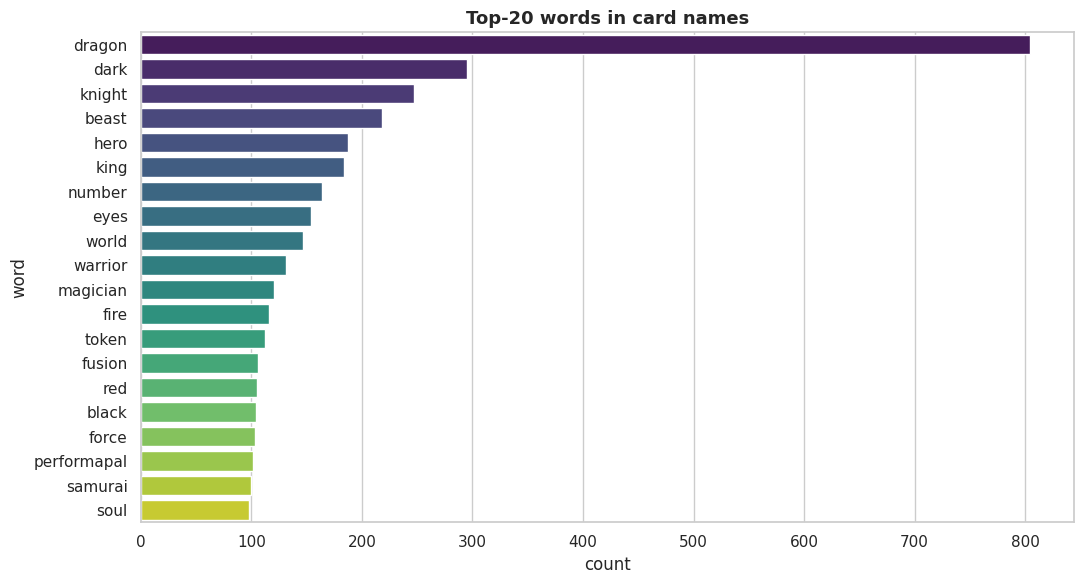

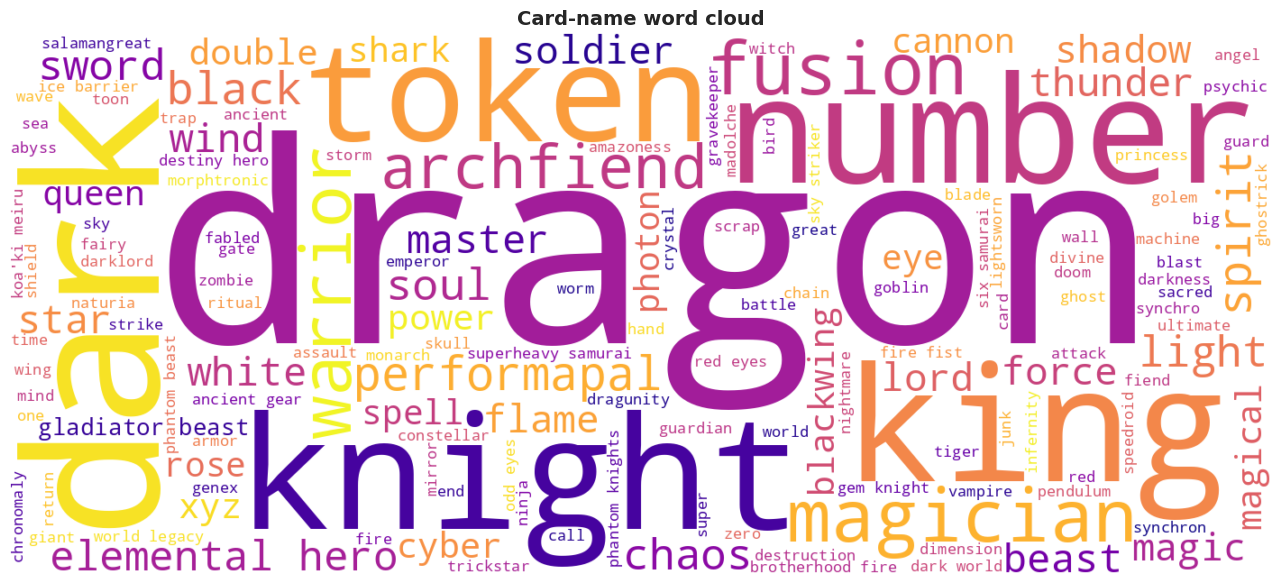

In [20]:
import re
from collections import Counter
from wordcloud import WordCloud


stop_extra = {"the", "of", "a", "an", "and", "in", "on", "to", "for", "with"}
name_tokens = []
for n in df["name"].fillna(""):
    toks = re.findall(r"[A-Za-z']+", n.lower())
    name_tokens.extend([t.strip("'") for t in toks if len(t.strip("'")) > 1 and t not in stop_extra])

cnt = Counter(name_tokens)
top_name = pd.DataFrame(cnt.most_common(25), columns=["word", "count"])
display(top_name)
top_name.to_csv(cfg.OUTPUT_DIR / "name_top_words.csv", index=False)

fig, ax = plt.subplots(figsize=(11, 6))
sns.barplot(data=top_name.head(20), x="count", y="word", hue="word", palette="viridis", legend=False, ax=ax)
ax.set_title("Top-20 words in card names", fontweight="bold", fontsize=13)
plt.tight_layout(); plt.savefig(cfg.OUTPUT_DIR / "name_top_words.png", dpi=150, bbox_inches="tight")
plt.show()

wc = WordCloud(width=1400, height=600, background_color="white", colormap="plasma",
                max_words=150).generate(" ".join(name_tokens))
fig, ax = plt.subplots(figsize=(14, 6))
ax.imshow(wc, interpolation="bilinear")
ax.axis("off")
ax.set_title("Card-name word cloud", fontweight="bold", fontsize=14)
plt.tight_layout(); plt.savefig(cfg.OUTPUT_DIR / "name_wordcloud.png", dpi=150, bbox_inches="tight")
plt.show()


## Text / Description NLP testing

`description` holds the actual card rules text (14,483 unique of 14,533 - near-unique). Pipeline: **(a)** length features (chars/words) overall + by card `type`, **(b)** Bag-of-Words unigrams/bigrams with sklearn `CountVectorizer`, **(c)** TF-IDF top terms split Monster vs Spell vs Trap, **(d)** word cloud + SVD semantic map. No downloads needed (sklearn English stop-words).

,desc_chars,desc_words
count,14533.0,14533.0
mean,313.5,56.0
std,163.2,29.4
min,2.0,1.0
25%,169.0,30.0
50%,313.0,56.0
75%,448.0,80.0
max,1006.0,188.0


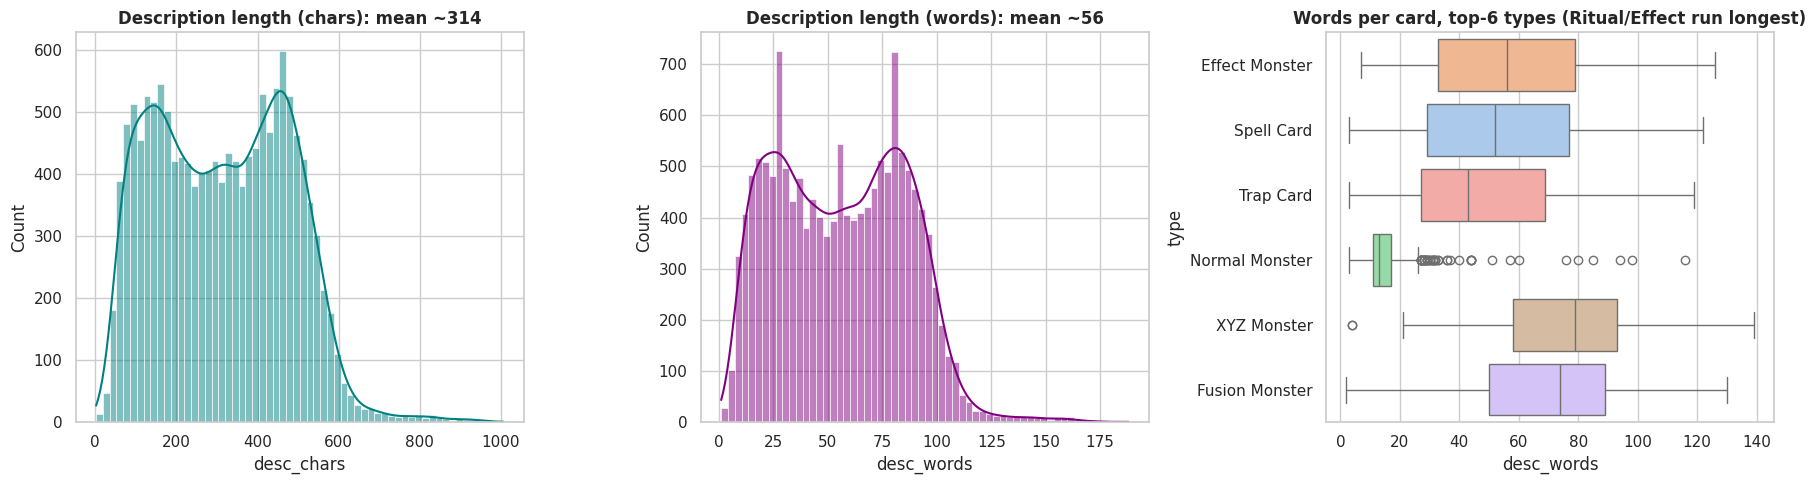

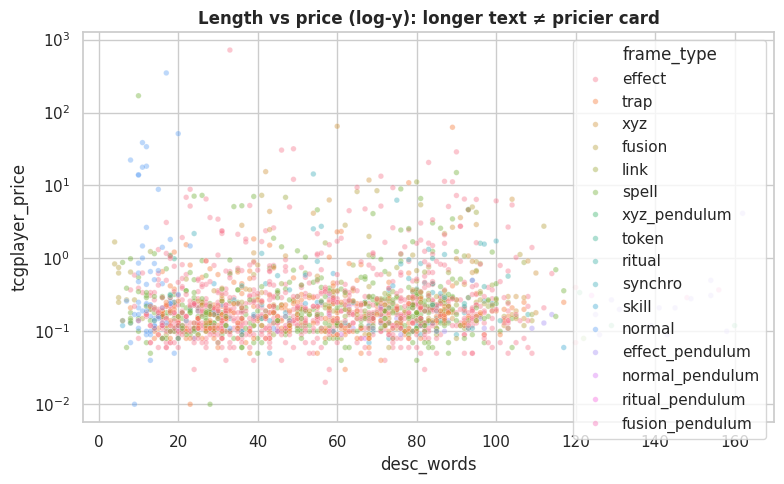

In [21]:
# (a) Length features
df["desc_chars"] = df["description"].fillna("").str.len()
df["desc_words"] = df["description"].fillna("").str.split().str.len()
display(df[["desc_chars", "desc_words"]].describe().round(1))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(df["desc_chars"], bins=60, kde=True, color="teal", ax=axes[0])
axes[0].set_title("Description length (chars): mean ~314", fontweight="bold")
sns.histplot(df["desc_words"], bins=60, kde=True, color="purple", ax=axes[1])
axes[1].set_title("Description length (words): mean ~56", fontweight="bold")
top_types = df["type"].value_counts().head(6).index
sns.boxplot(data=df[df["type"].isin(top_types)], x="desc_words", y="type",
            order=df.loc[df["type"].isin(top_types), "type"].value_counts().index,
            palette="pastel", hue="type", legend=False, ax=axes[2])
axes[2].set_title("Words per card, top-6 types (Ritual/Effect run longest)", fontweight="bold")
plt.tight_layout(); plt.savefig(cfg.OUTPUT_DIR / "nlp_lengths.png", dpi=150, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=df.sample(2000, random_state=cfg.SEED), x="desc_words",
                y="tcgplayer_price", hue="frame_type", alpha=0.4, s=16, ax=ax)
ax.set_yscale("log")
ax.set_title("Length vs price (log-y): longer text ≠ pricier card", fontweight="bold")
plt.tight_layout(); plt.savefig(cfg.OUTPUT_DIR / "nlp_length_vs_price.png", dpi=150, bbox_inches="tight")
plt.show()


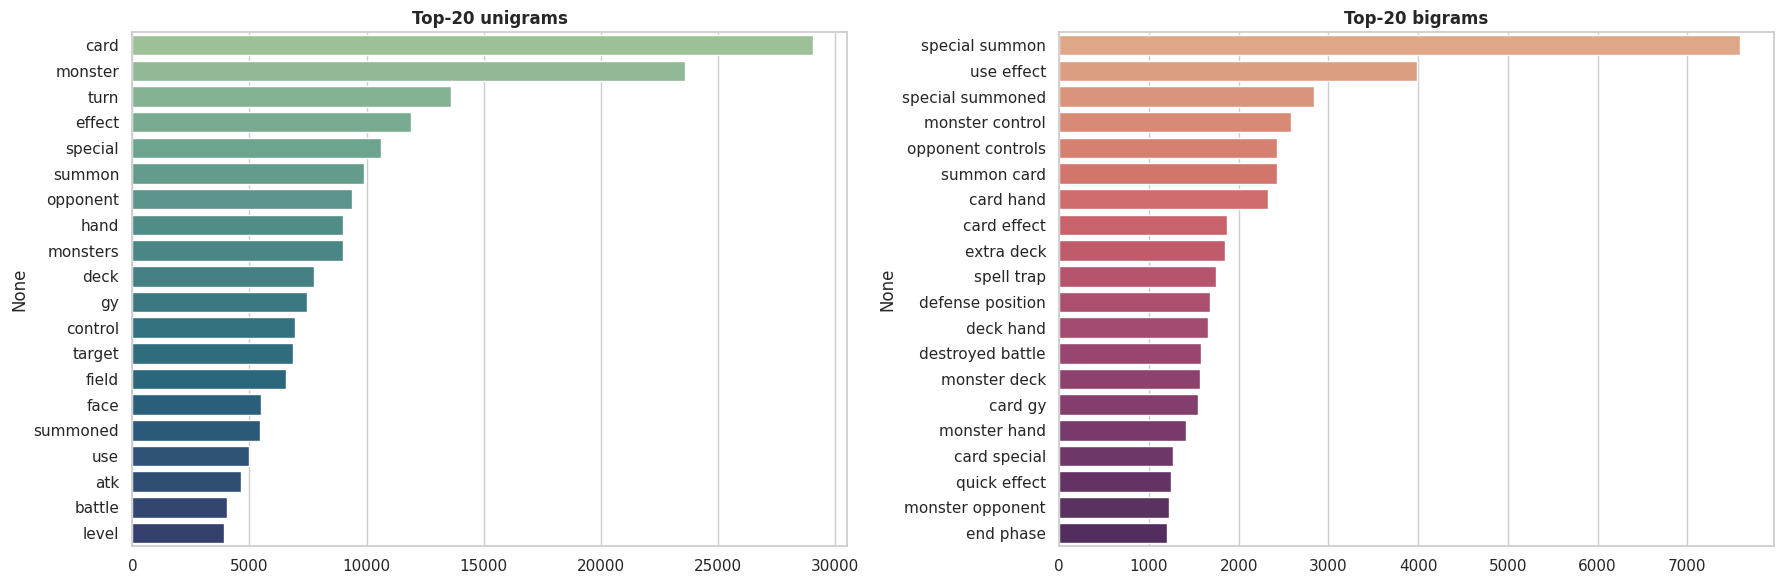

Unigrams: {'card': 29070, 'monster': 23598, 'turn': 13613, 'effect': 11917, 'special': 10615, 'summon': 9879, 'opponent': 9375, 'hand': 9008, 'monsters': 8998, 'deck': 7764}
Bigrams: {'special summon': 7588, 'use effect': 3989, 'special summoned': 2840, 'monster control': 2583, 'opponent controls': 2431, 'summon card': 2422, 'card hand': 2322, 'card effect': 1873, 'extra deck': 1843, 'spell trap': 1746}


In [22]:
# (b) BoW: top unigrams + bigrams (CountVectorizer, english stop-words, min_df=5)
from sklearn.feature_extraction.text import CountVectorizer

texts = df["description"].fillna("")
uni = CountVectorizer(stop_words="english", max_features=25, min_df=5)
Xu = uni.fit_transform(texts)
freq_u = pd.Series(np.asarray(Xu.sum(axis=0)).ravel(), index=uni.get_feature_names_out()
                   ).sort_values(ascending=False)

bi = CountVectorizer(stop_words="english", ngram_range=(2, 2), max_features=25, min_df=5)
Xb = bi.fit_transform(texts)
freq_b = pd.Series(np.asarray(Xb.sum(axis=0)).ravel(), index=bi.get_feature_names_out()
                   ).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
sns.barplot(x=freq_u.head(20).values, y=freq_u.head(20).index, hue=freq_u.head(20).index,
            palette="crest", legend=False, ax=axes[0])
axes[0].set_title("Top-20 unigrams", fontweight="bold")
sns.barplot(x=freq_b.head(20).values, y=freq_b.head(20).index, hue=freq_b.head(20).index,
            palette="flare", legend=False, ax=axes[1])
axes[1].set_title("Top-20 bigrams", fontweight="bold")
plt.tight_layout(); plt.savefig(cfg.OUTPUT_DIR / "nlp_bow.png", dpi=150, bbox_inches="tight")
plt.show()
print("Unigrams:", freq_u.head(10).to_dict())
print("Bigrams:", freq_b.head(10).to_dict())


,Monster,Spell,Trap
card,0.1249,0.0915,0.1129
control,NaN,NaN,0.0620
deck,NaN,0.0607,NaN
effect,0.0591,NaN,0.0615
field,NaN,NaN,0.0579
gy,NaN,0.0542,0.0555
hand,0.0536,0.0593,NaN
monster,0.0923,0.1125,0.1261
monsters,0.0534,0.0617,0.0616
opponent,0.0574,0.0535,0.0780


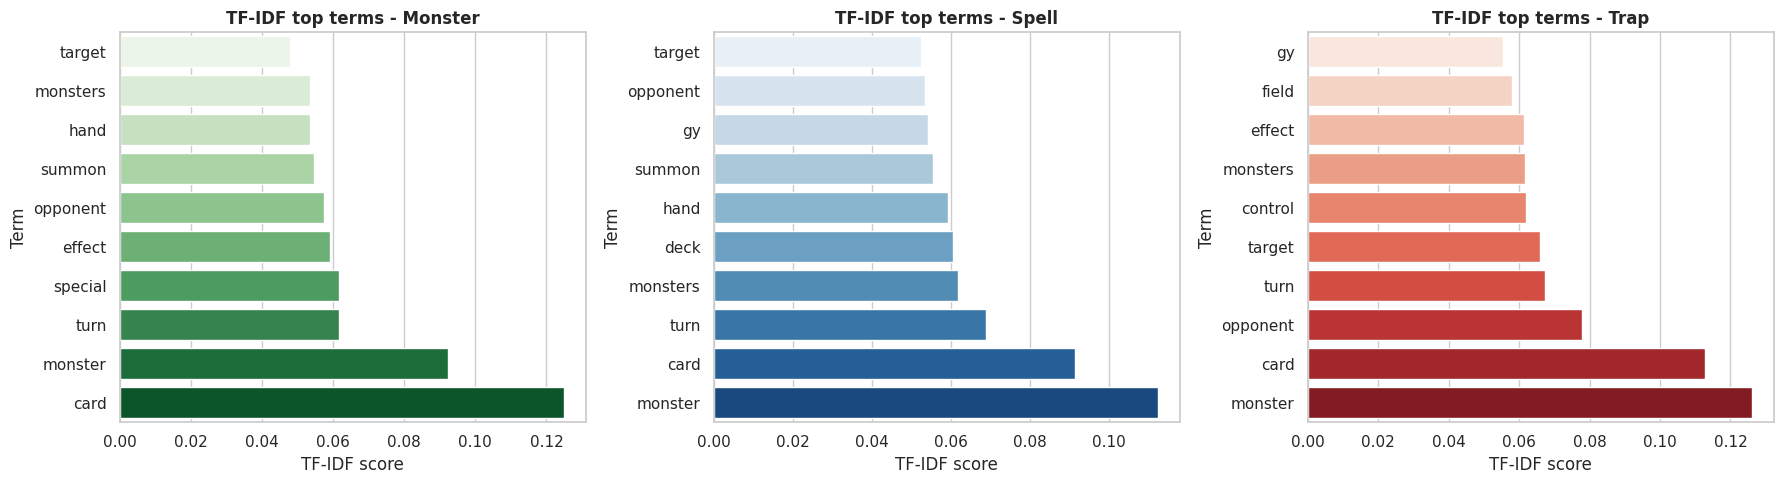

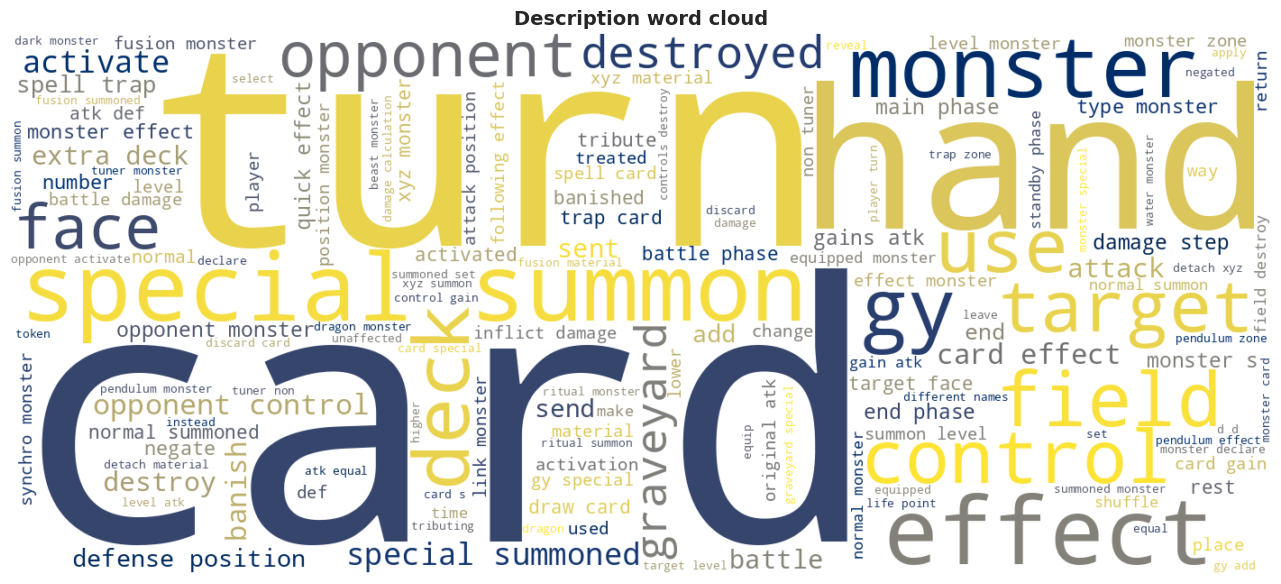

In [23]:
# (c) TF-IDF contrast: what vocabulary DEFINES each card family?
from sklearn.feature_extraction.text import TfidfVectorizer

def top_tfidf(sub: pd.Series, k=10):
    v = TfidfVectorizer(stop_words="english", max_features=3000, min_df=5)
    X = v.fit_transform(sub.fillna(""))
    scores = np.asarray(X.mean(axis=0)).ravel()
    return pd.Series(scores, index=v.get_feature_names_out()).sort_values(ascending=False).head(k)

is_mon = df["frame_type"].isin(["effect", "normal", "fusion", "synchro", "xyz", "link"])
is_spell = df["frame_type"] == "spell"
is_trap = df["frame_type"] == "trap"
terms = pd.DataFrame({
    "Monster": top_tfidf(df.loc[is_mon, "description"]),
    "Spell": top_tfidf(df.loc[is_spell, "description"]),
    "Trap": top_tfidf(df.loc[is_trap, "description"]),
})
display(terms.round(4))
terms.to_csv(cfg.OUTPUT_DIR / "nlp_tfidf_by_family.csv")

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=False)
for ax, col, color in zip(axes, ["Monster", "Spell", "Trap"], ["Greens", "Blues", "Reds"]):
    s = terms[col].dropna().sort_values()
    sns.barplot(x=s.values, y=s.index, hue=s.index, palette=color, legend=False, ax=ax)
    ax.set_xlabel("TF-IDF score")
    ax.set_ylabel("Term")
    ax.set_title(f"TF-IDF top terms - {col}", fontweight="bold")
plt.tight_layout(); plt.savefig(cfg.OUTPUT_DIR / "nlp_tfidf.png", dpi=150, bbox_inches="tight")
plt.show()

# (d) Description word cloud
desc_wc = WordCloud(width=1400, height=600, background_color="white", colormap="cividis",
                    max_words=150, stopwords=set(uni.get_stop_words()) if hasattr(uni, "get_stop_words") else None
                    ).generate(" ".join(df["description"].fillna("").str.lower()))
fig, ax = plt.subplots(figsize=(14, 6))
ax.imshow(desc_wc, interpolation="bilinear"); ax.axis("off")
ax.set_title("Description word cloud", fontweight="bold", fontsize=14)
plt.tight_layout(); plt.savefig(cfg.OUTPUT_DIR / "nlp_wordcloud.png", dpi=150, bbox_inches="tight")
plt.show()


card description mosly dominate by the in-game terms like, `turn`, `card`, and `hand`. Each card type also have different description occurance, we can see it using TF-iDF